In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_palette("pastel")
sns.set_style("whitegrid")

In [4]:
import os



# Show current directory
print("Current working directory:", os.getcwd())

# If not correct, set it manually:
os.chdir("D:/Harshali/Projects/miniprojectTY/stroke awareness")  # e.g. "C:/Users/Harshali/Desktop/ML_Project"

print("✅ Changed working directory to:", os.getcwd())



Current working directory: C:\Users\Harshali g
✅ Changed working directory to: D:\Harshali\Projects\miniprojectTY\stroke awareness


In [4]:
# Load your cleaned file
df = pd.read_csv("awareness_scores_with_categories.csv")

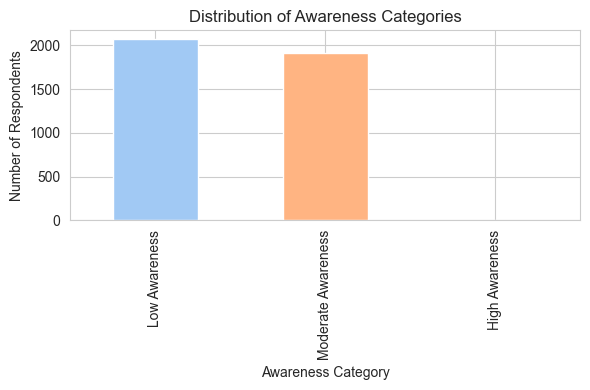

In [5]:


plt.figure(figsize=(6, 4))
df['awareness_category'].value_counts().plot(kind='bar', color=sns.color_palette("pastel"))
plt.title("Distribution of Awareness Categories")
plt.xlabel("Awareness Category")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()


C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\4282405635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='awareness_score', data=df, palette="pastel")


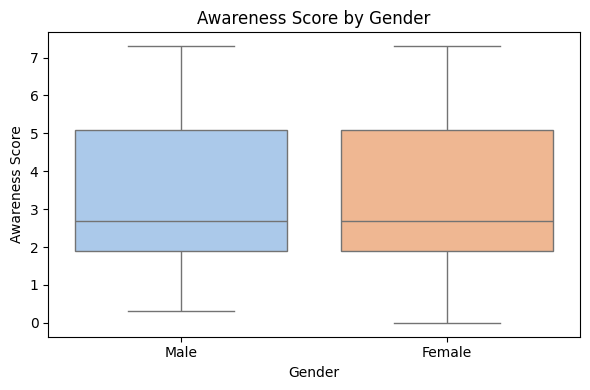

In [15]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='gender', y='awareness_score', data=df, palette="pastel")
plt.title("Awareness Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Awareness Score")
plt.tight_layout()
plt.show()


C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\2487834888.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='educational_level', y='awareness_score', data=df, palette="pastel")


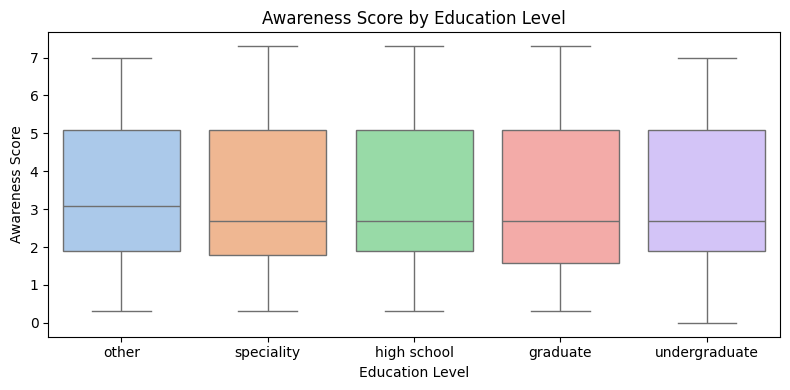

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='educational_level', y='awareness_score', data=df, palette="pastel")
plt.title("Awareness Score by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Awareness Score")
plt.tight_layout()
plt.show()


In [17]:
print(pd.crosstab(df['awareness_category'], df['gender']))
print(pd.crosstab(df['awareness_category'], df['educational_level']))


gender              Female  Male
awareness_category              
High Awareness           1     2
Low Awareness         1154   915
Moderate Awareness    1108   803
educational_level   graduate  high school  other  speciality  undergraduate
awareness_category                                                         
High Awareness             1            1      0           1              0
Low Awareness            713         1027    108          59            162
Moderate Awareness       649          953    116          48            145


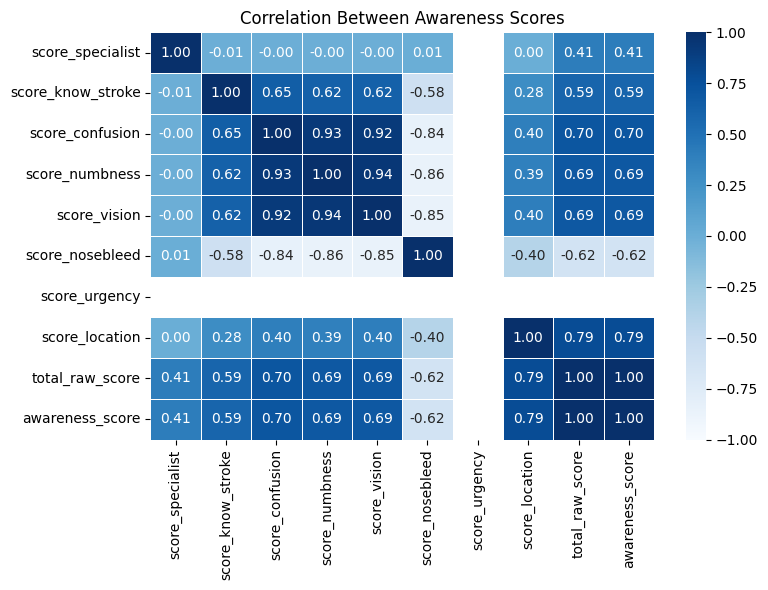

In [18]:
score_cols = [
    'score_specialist', 'score_know_stroke', 'score_confusion',
    'score_numbness', 'score_vision', 'score_nosebleed',
    'score_urgency', 'score_location', 'total_raw_score', 'awareness_score'
]

plt.figure(figsize=(8, 6))
corr = df[score_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, linewidths=.5, fmt='.2f')
plt.title("Correlation Between Awareness Scores")
plt.tight_layout()
plt.show()


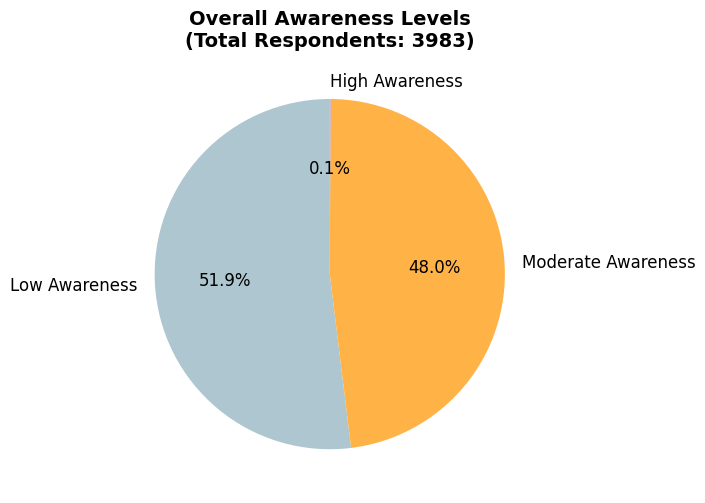

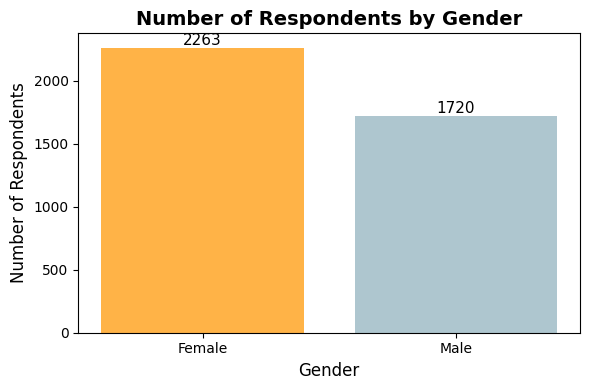

<Figure size 800x500 with 0 Axes>

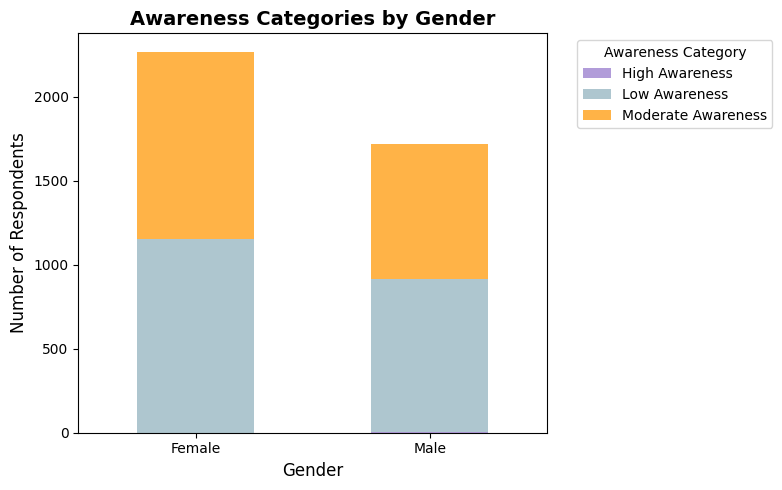

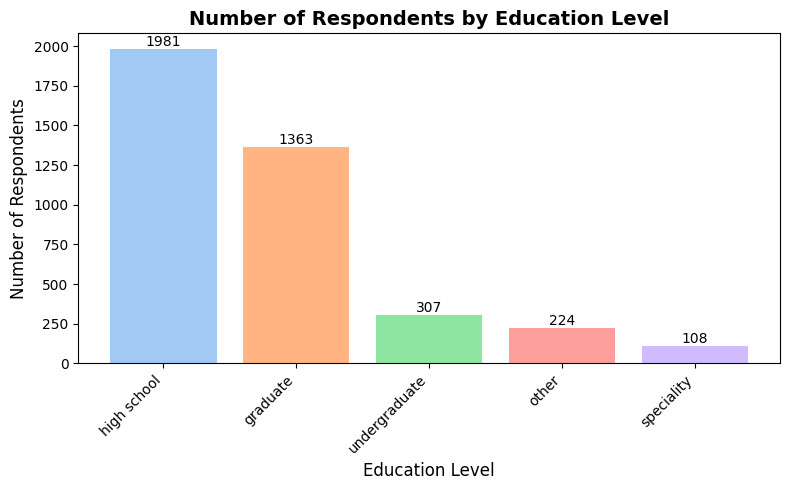

<Figure size 1000x600 with 0 Axes>

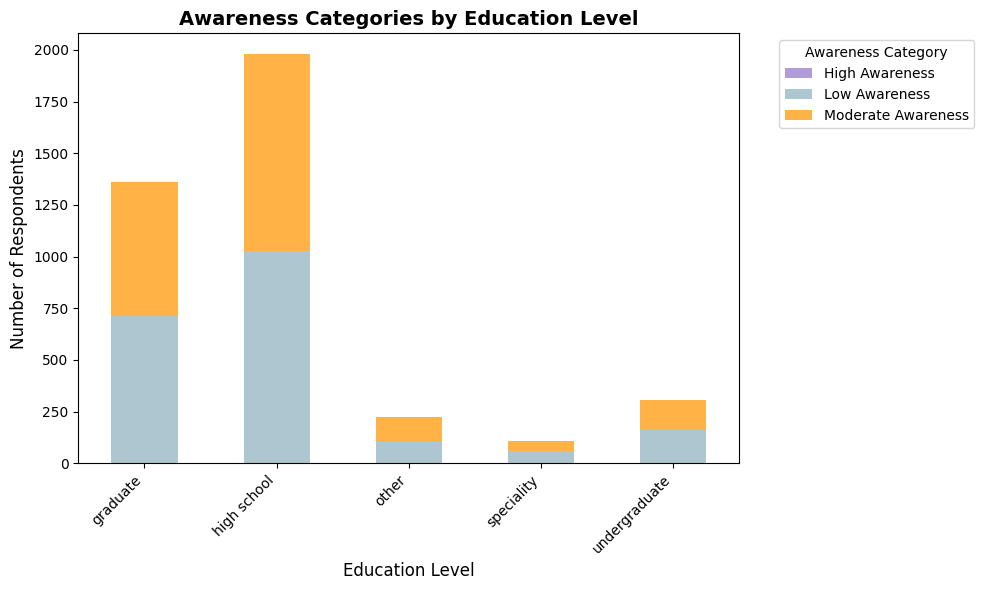


SUMMARY TABLE: Awareness Category Distribution
Awareness Category  Number of Respondents Percentage
     Low Awareness                   2069      51.9%
Moderate Awareness                   1911      48.0%
    High Awareness                      3       0.1%


In [20]:


# ============================================
# 1. PIE CHART: Overall Awareness Levels
# ============================================
category_counts = df['awareness_category'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#AEC6CF', '#FFB347', '#B19CD9']  # Soft blue, peach, lavender
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 12})
plt.title('Overall Awareness Levels\n(Total Respondents: 3983)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 2. BAR CHART: Number of Respondents by Gender
# ============================================
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(gender_counts.index, gender_counts.values, color=['#FFB347', '#AEC6CF'])
plt.title('Number of Respondents by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# 3. STACKED BAR CHART: Awareness Categories by Gender
# ============================================
category_by_gender = pd.crosstab(df['gender'], df['awareness_category'])

plt.figure(figsize=(8, 5))
category_by_gender.plot(kind='bar', stacked=True, color=['#B19CD9', '#AEC6CF', '#FFB347'], 
                        figsize=(8, 5))
plt.title('Awareness Categories by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 4. BAR CHART: Number of Respondents by Education Level
# ============================================
education_counts = df['educational_level'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(education_counts.index, education_counts.values, 
               color=sns.color_palette("pastel", len(education_counts)))
plt.title('Number of Respondents by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# 5. STACKED BAR CHART: Awareness Categories by Education Level
# ============================================
category_by_education = pd.crosstab(df['educational_level'], df['awareness_category'])
category_by_education = category_by_education.sort_index()

plt.figure(figsize=(10, 6))
category_by_education.plot(kind='bar', stacked=True, color=['#B19CD9', '#AEC6CF', '#FFB347'], 
                           figsize=(10, 6))
plt.title('Awareness Categories by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 6. TABLE: Summary of Awareness Categories
# ============================================
print("\n" + "="*60)
print("SUMMARY TABLE: Awareness Category Distribution")
print("="*60)
table_data = pd.DataFrame({
    'Awareness Category': category_counts.index,
    'Number of Respondents': category_counts.values,
    'Percentage': [f"{(count/len(df)*100):.1f}%" for count in category_counts.values]
})
print(table_data.to_string(index=False))
print("="*60)


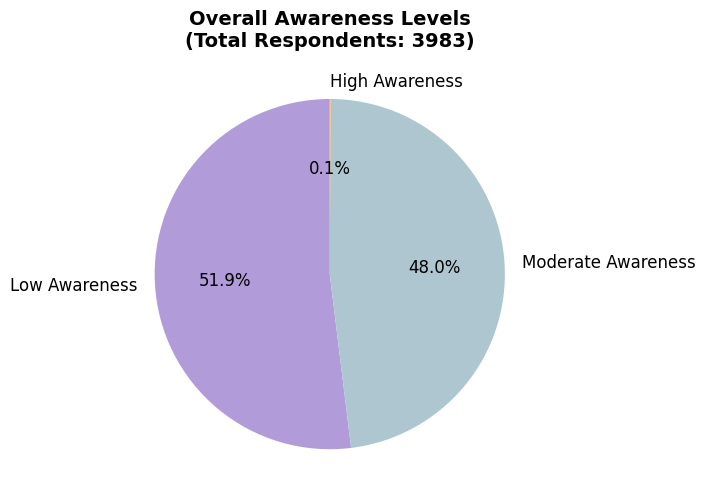

<Figure size 800x500 with 0 Axes>

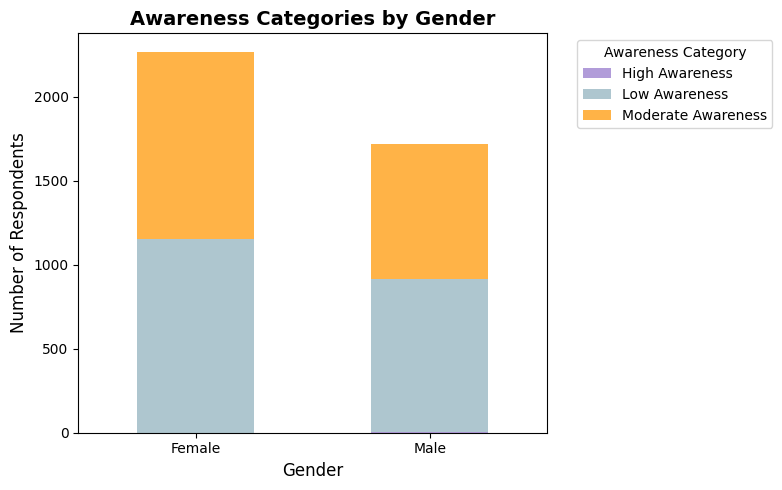

<Figure size 1000x500 with 0 Axes>

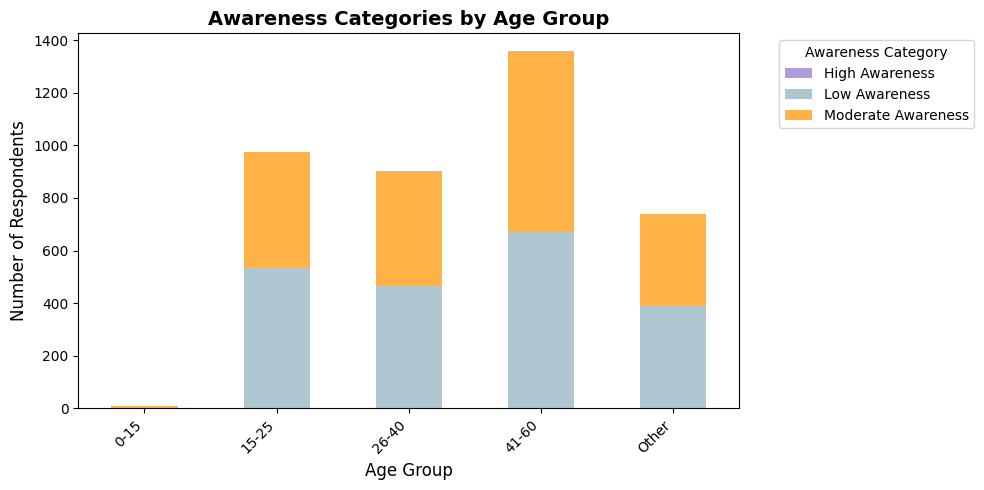

<Figure size 1000x600 with 0 Axes>

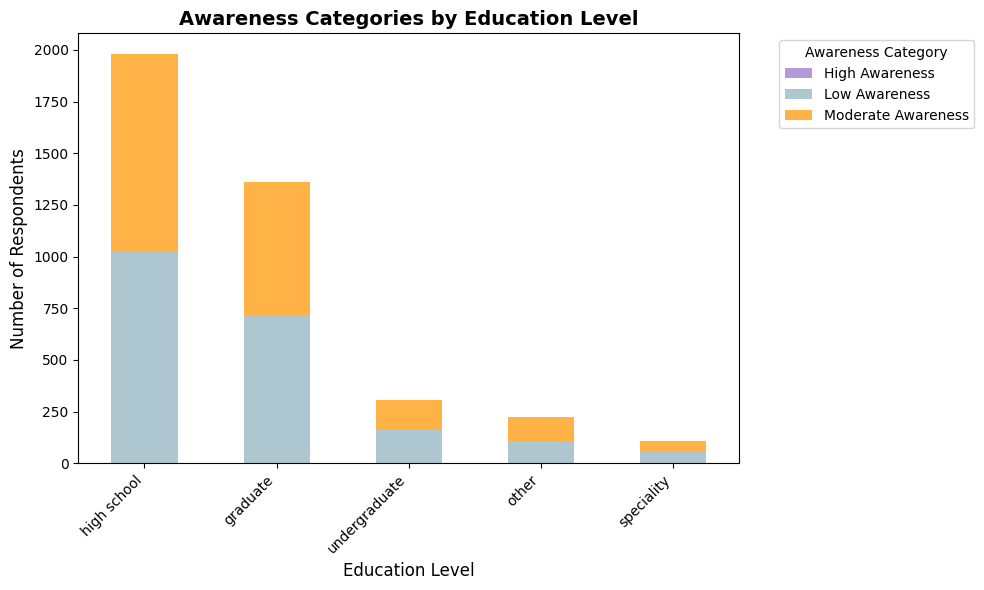

<Figure size 1000x600 with 0 Axes>

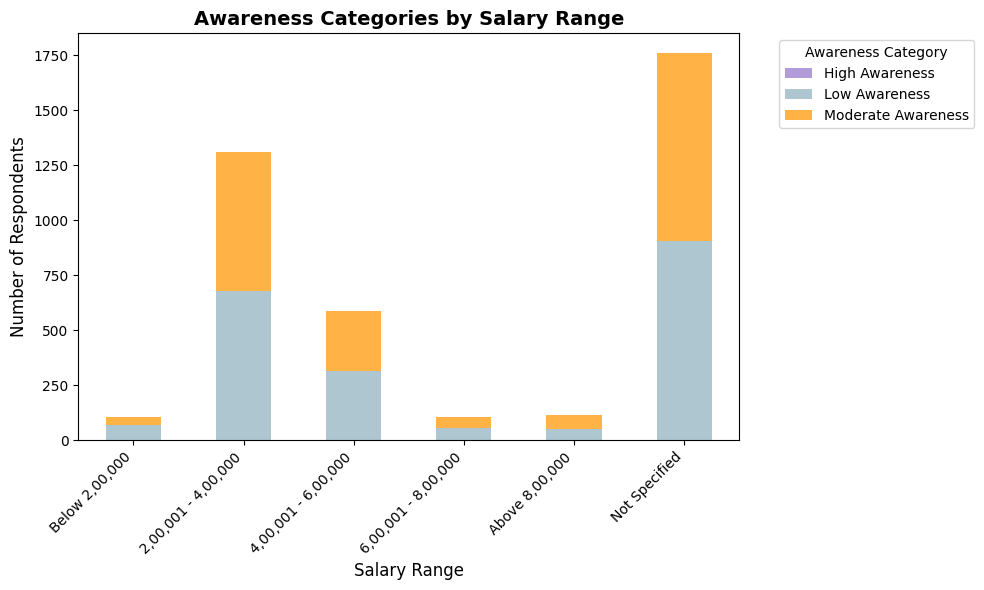

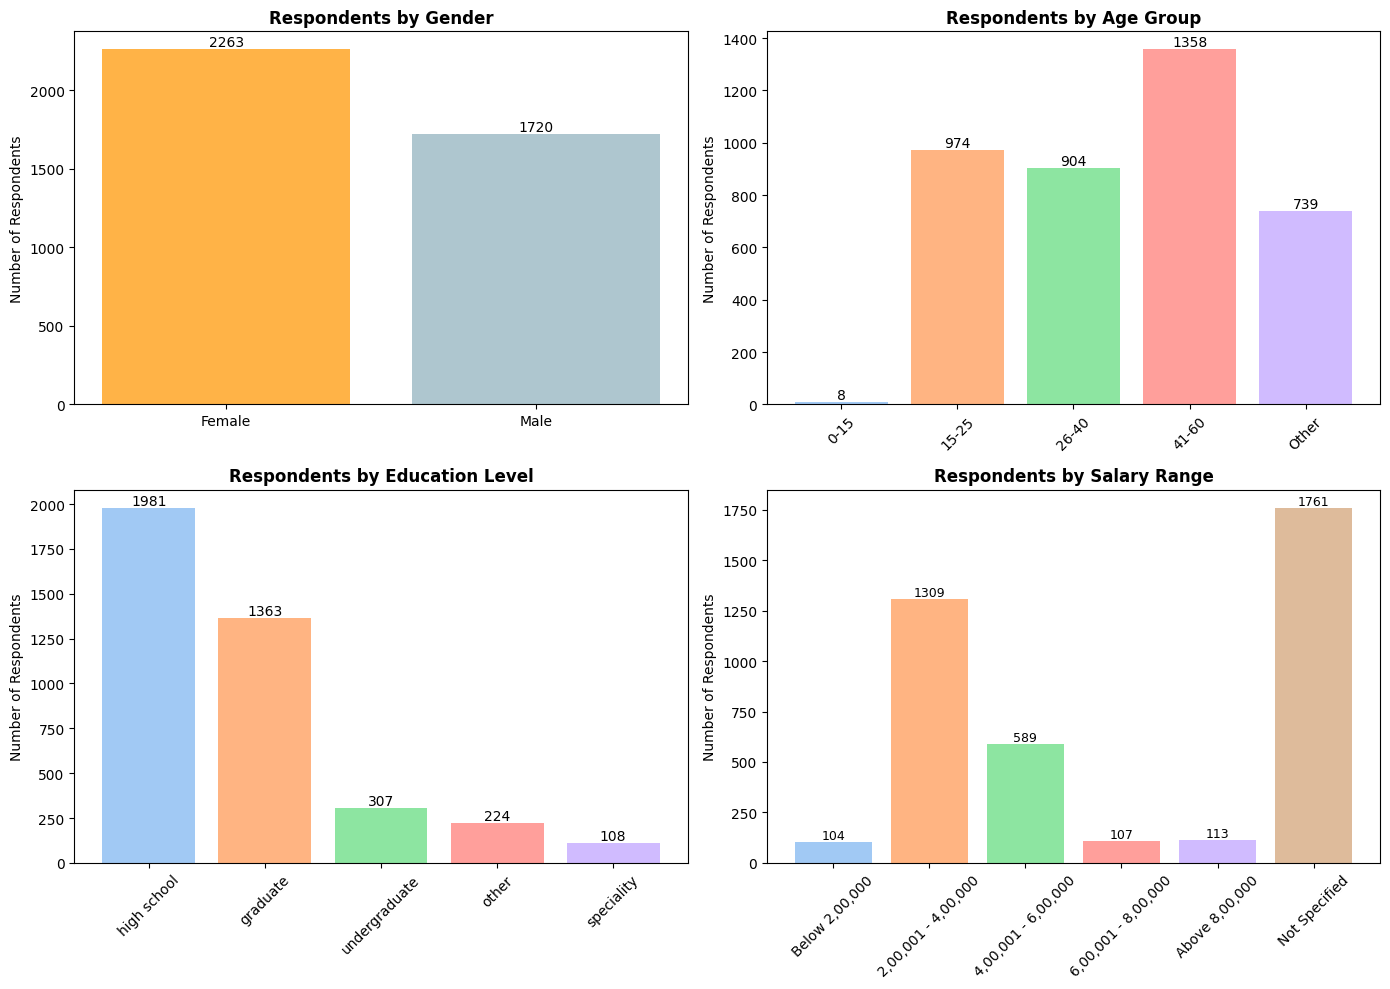


DEMOGRAPHIC SUMMARY TABLES

1. AWARENESS BY AGE GROUP (Count and Percentage)
----------------------------------------------------------------------
awareness_category High Awareness Low Awareness Moderate Awareness
age                                                               
0-15                     0 (0.0%)     5 (62.5%)          3 (37.5%)
15-25                    1 (0.1%)   536 (55.0%)        437 (44.9%)
26-40                    0 (0.0%)   470 (52.0%)        434 (48.0%)
41-60                    1 (0.1%)   671 (49.4%)        686 (50.5%)
Other                    1 (0.1%)   387 (52.4%)        351 (47.5%)

2. AWARENESS BY GENDER (Count and Percentage)
----------------------------------------------------------------------
awareness_category High Awareness Low Awareness Moderate Awareness
gender                                                            
Female                   1 (0.0%)  1154 (51.0%)       1108 (49.0%)
Male                     2 (0.1%)   915 (53.2%)        803 (46.

In [21]:


# Define consistent colors
colors_awareness = ['#B19CD9', '#AEC6CF', '#FFB347']  # High, Low, Moderate

# ============================================
# 1. PIE CHART: Overall Awareness Levels
# ============================================
category_counts = df['awareness_category'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=colors_awareness, startangle=90, textprops={'fontsize': 12})
plt.title('Overall Awareness Levels\n(Total Respondents: 3983)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 2. STACKED BAR: Awareness by Gender
# ============================================
awareness_by_gender = pd.crosstab(df['gender'], df['awareness_category'])

plt.figure(figsize=(8, 5))
awareness_by_gender.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(8, 5))
plt.title('Awareness Categories by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 3. STACKED BAR: Awareness by Age Group
# ============================================
awareness_by_age = pd.crosstab(df['age'], df['awareness_category'])
# Reorder age groups logically
age_order = ['0-15', '15-25', '26-40', '41-60', 'Other']
awareness_by_age = awareness_by_age.reindex(age_order)

plt.figure(figsize=(10, 5))
awareness_by_age.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(10, 5))
plt.title('Awareness Categories by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 4. STACKED BAR: Awareness by Education Level
# ============================================
awareness_by_education = pd.crosstab(df['educational_level'], df['awareness_category'])
# Sort by total count
awareness_by_education = awareness_by_education.loc[awareness_by_education.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))
awareness_by_education.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(10, 6))
plt.title('Awareness Categories by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 5. STACKED BAR: Awareness by Salary Range
# ============================================
awareness_by_salary = pd.crosstab(df['salary'], df['awareness_category'])
# Logical order for salary
salary_order = ['Below 2,00,000', '2,00,001 - 4,00,000', '4,00,001 - 6,00,000', 
                '6,00,001 - 8,00,000', 'Above 8,00,000', 'Not Specified']
awareness_by_salary = awareness_by_salary.reindex(salary_order)

plt.figure(figsize=(10, 6))
awareness_by_salary.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(10, 6))
plt.title('Awareness Categories by Salary Range', fontsize=14, fontweight='bold')
plt.xlabel('Salary Range', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 6. GROUPED BAR: Respondent Count by Demographics
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_counts = df['gender'].value_counts()
axes[0, 0].bar(gender_counts.index, gender_counts.values, color=['#FFB347', '#AEC6CF'])
axes[0, 0].set_title('Respondents by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Respondents')
for i, v in enumerate(gender_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom')

# Age Group
age_counts = df['age'].value_counts().reindex(age_order)
axes[0, 1].bar(age_counts.index, age_counts.values, color=sns.color_palette("pastel", 5))
axes[0, 1].set_title('Respondents by Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Number of Respondents')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom')

# Education Level
education_counts = df['educational_level'].value_counts().sort_values(ascending=False)
axes[1, 0].bar(education_counts.index, education_counts.values, color=sns.color_palette("pastel", len(education_counts)))
axes[1, 0].set_title('Respondents by Education Level', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Respondents')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(education_counts.values):
    axes[1, 0].text(i, v, str(v), ha='center', va='bottom')

# Salary Range
salary_counts = df['salary'].value_counts().reindex(salary_order)
axes[1, 1].bar(salary_counts.index, salary_counts.values, color=sns.color_palette("pastel", 6))
axes[1, 1].set_title('Respondents by Salary Range', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Respondents')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(salary_counts.values):
    axes[1, 1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# 7. SUMMARY TABLES
# ============================================
print("\n" + "="*70)
print("DEMOGRAPHIC SUMMARY TABLES")
print("="*70)

print("\n1. AWARENESS BY AGE GROUP (Count and Percentage)")
print("-"*70)
awareness_by_age_pct = pd.crosstab(df['age'], df['awareness_category'], normalize='index') * 100
combined_age = awareness_by_age.copy()
for col in awareness_by_age.columns:
    combined_age[col] = awareness_by_age[col].astype(str) + ' (' + awareness_by_age_pct[col].round(1).astype(str) + '%)'
print(combined_age)

print("\n2. AWARENESS BY GENDER (Count and Percentage)")
print("-"*70)
awareness_by_gender_pct = pd.crosstab(df['gender'], df['awareness_category'], normalize='index') * 100
combined_gender = awareness_by_gender.copy()
for col in awareness_by_gender.columns:
    combined_gender[col] = awareness_by_gender[col].astype(str) + ' (' + awareness_by_gender_pct[col].round(1).astype(str) + '%)'
print(combined_gender)

print("\n3. AWARENESS BY EDUCATION LEVEL (Count and Percentage)")
print("-"*70)
awareness_by_education_pct = pd.crosstab(df['educational_level'], df['awareness_category'], normalize='index') * 100
combined_education = awareness_by_education.copy()
for col in awareness_by_education.columns:
    combined_education[col] = awareness_by_education[col].astype(str) + ' (' + awareness_by_education_pct[col].round(1).astype(str) + '%)'
print(combined_education)

print("\n4. AWARENESS BY SALARY RANGE (Count and Percentage)")
print("-"*70)
awareness_by_salary_pct = pd.crosstab(df['salary'], df['awareness_category'], normalize='index') * 100
combined_salary = awareness_by_salary.copy()
for col in awareness_by_salary.columns:
    combined_salary[col] = awareness_by_salary[col].astype(str) + ' (' + awareness_by_salary_pct[col].round(1).astype(str) + '%)'
print(combined_salary.reindex(salary_order))

print("\n" + "="*70)


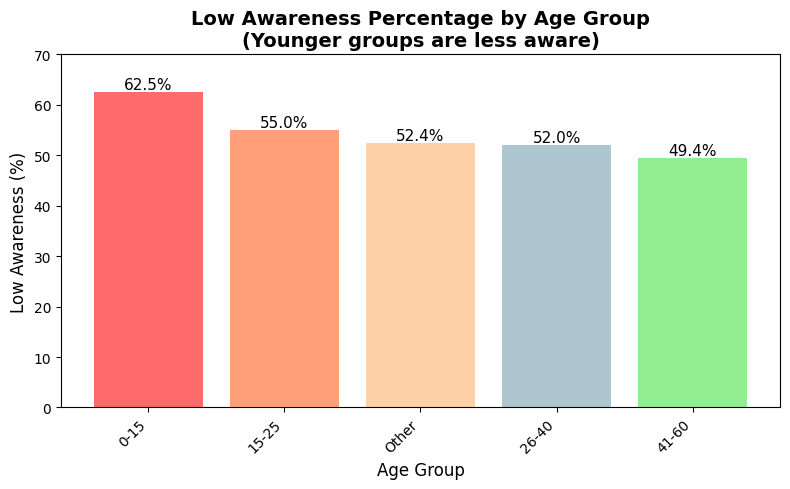

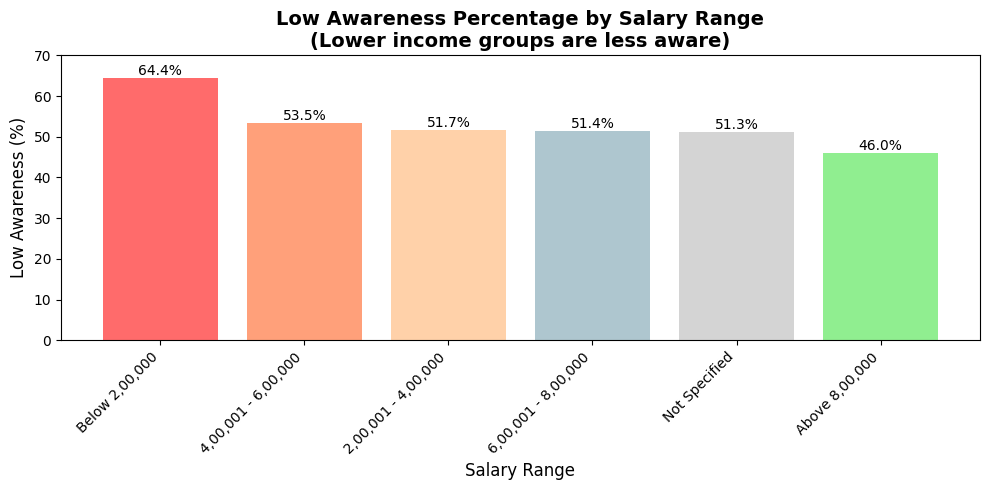

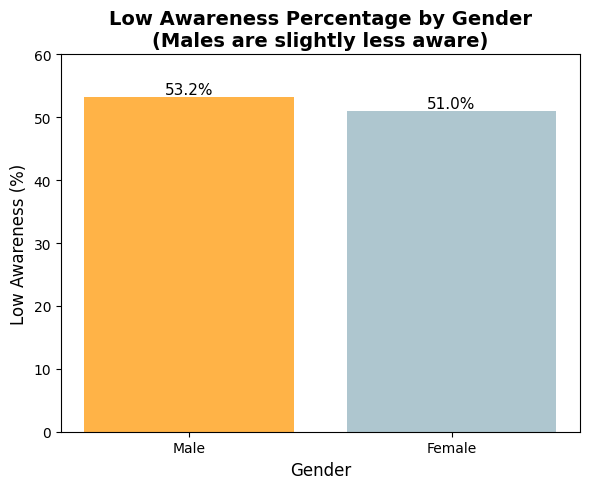

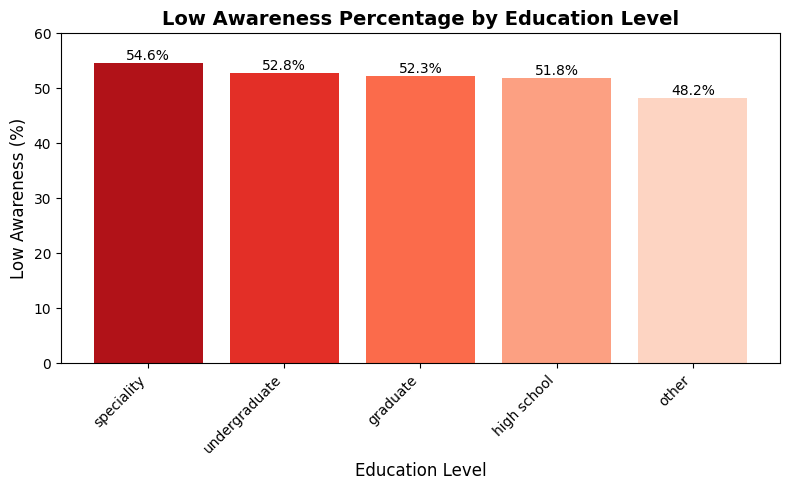

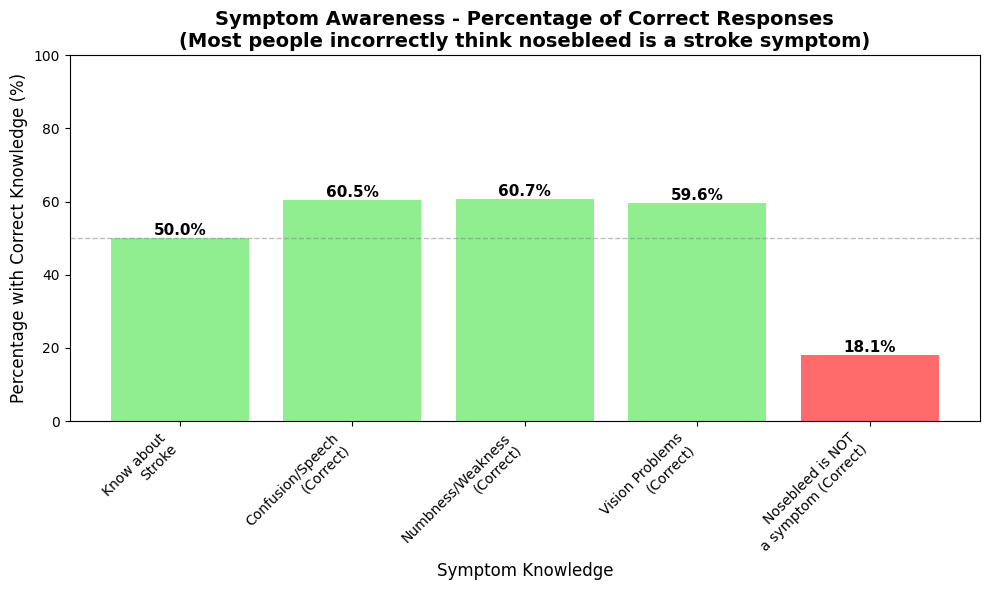

<Figure size 1200x600 with 0 Axes>

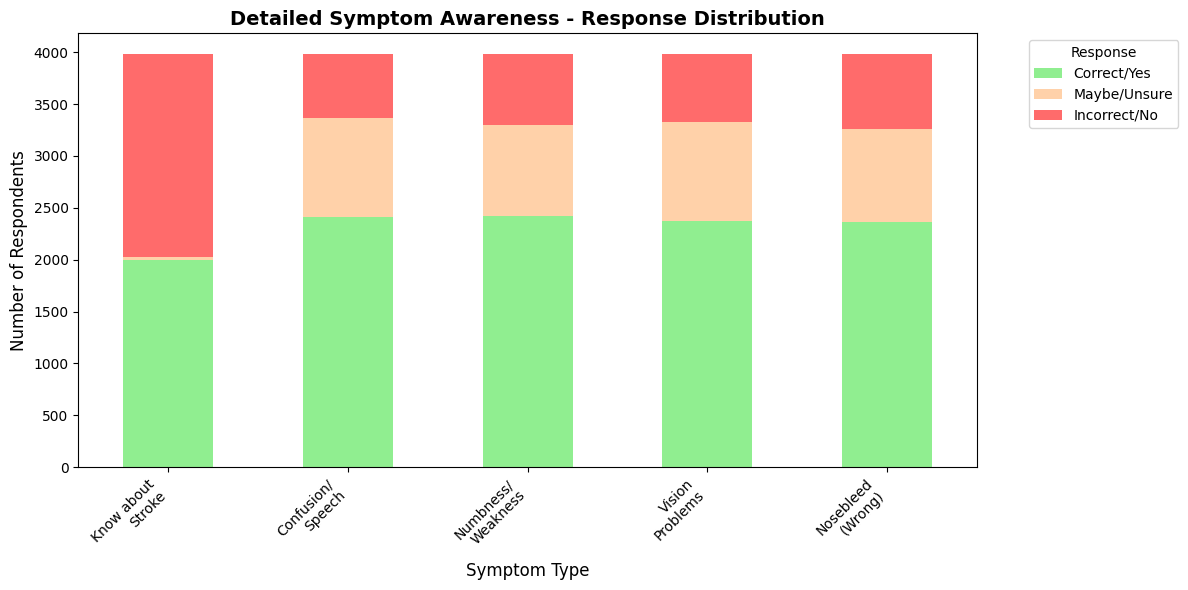


SUMMARY: LEAST AWARE DEMOGRAPHIC GROUPS

1. AGE: 0-15 years (62.5% Low Awareness)
2. AGE: 15-25 years (55.0% Low Awareness)
3. SALARY: Below 2,00,000 (64.4% Low Awareness)
4. GENDER: Male (53.2% Low Awareness vs 51.0% Female)
5. EDUCATION: Speciality (54.6% Low Awareness)

SUMMARY: SYMPTOM AWARENESS GAPS

1. Only 50.0% know what a brain stroke is
2. 60.5% correctly identify confusion/speech as symptom
3. 60.7% correctly identify numbness/weakness as symptom
4. 59.6% correctly identify vision problems as symptom
5. Only 18.1% correctly know nosebleed is NOT a stroke symptom
   → 59.3% WRONGLY think nosebleed is a stroke symptom!


In [22]:


# ============================================
# PART 1: LEAST AWARE DEMOGRAPHICS
# ============================================

# Calculate LOW awareness percentages by demographics
age_low = pd.crosstab(df['age'], df['awareness_category'], normalize='index') * 100
gender_low = pd.crosstab(df['gender'], df['awareness_category'], normalize='index') * 100
education_low = pd.crosstab(df['educational_level'], df['awareness_category'], normalize='index') * 100
salary_low = pd.crosstab(df['salary'], df['awareness_category'], normalize='index') * 100

# 1. Bar Chart: Low Awareness % by Age
plt.figure(figsize=(8, 5))
age_low_sorted = age_low['Low Awareness'].sort_values(ascending=False)
age_order = ['0-15', '15-25', 'Other', '26-40', '41-60']
age_low_ordered = age_low['Low Awareness'].reindex(age_order)
bars = plt.bar(age_low_ordered.index, age_low_ordered.values, color=['#FF6B6B', '#FFA07A', '#FFD1A9', '#AEC6CF', '#90EE90'])
plt.title('Low Awareness Percentage by Age Group\n(Younger groups are less aware)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Low Awareness (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 70)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# 2. Bar Chart: Low Awareness % by Salary
plt.figure(figsize=(10, 5))
salary_order = ['Below 2,00,000', '4,00,001 - 6,00,000', '2,00,001 - 4,00,000', 
                '6,00,001 - 8,00,000', 'Not Specified', 'Above 8,00,000']
salary_low_ordered = salary_low['Low Awareness'].reindex(salary_order)
bars = plt.bar(salary_low_ordered.index, salary_low_ordered.values, 
               color=['#FF6B6B', '#FFA07A', '#FFD1A9', '#AEC6CF', '#D4D4D4', '#90EE90'])
plt.title('Low Awareness Percentage by Salary Range\n(Lower income groups are less aware)', fontsize=14, fontweight='bold')
plt.xlabel('Salary Range', fontsize=12)
plt.ylabel('Low Awareness (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 70)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 3. Bar Chart: Low Awareness % by Gender
plt.figure(figsize=(6, 5))
gender_low_sorted = gender_low['Low Awareness'].sort_values(ascending=False)
bars = plt.bar(gender_low_sorted.index, gender_low_sorted.values, color=['#FFB347', '#AEC6CF'])
plt.title('Low Awareness Percentage by Gender\n(Males are slightly less aware)', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Low Awareness (%)', fontsize=12)
plt.ylim(0, 60)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# 4. Bar Chart: Low Awareness % by Education
plt.figure(figsize=(8, 5))
education_low_sorted = education_low['Low Awareness'].sort_values(ascending=False)
bars = plt.bar(education_low_sorted.index, education_low_sorted.values, 
               color=sns.color_palette("Reds_r", len(education_low_sorted)))
plt.title('Low Awareness Percentage by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Low Awareness (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 60)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# PART 2: SYMPTOM AWARENESS
# ============================================

# Calculate correct response percentages
total = len(df)
symptom_awareness = {
    'Know about\nStroke': (df['do_you_know_what_is_a_brain_stroke?'] == 'Yes').sum() / total * 100,
    'Confusion/Speech\n(Correct)': (df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'] == 'yes').sum() / total * 100,
    'Numbness/Weakness\n(Correct)': (df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'] == 'yes').sum() / total * 100,
    'Vision Problems\n(Correct)': (df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'] == 'yes').sum() / total * 100,
    'Nosebleed is NOT\na symptom (Correct)': (df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'] == 'no').sum() / total * 100
}

# 5. Bar Chart: Symptom Recognition (Correct Responses)
plt.figure(figsize=(10, 6))
symptoms = list(symptom_awareness.keys())
percentages = list(symptom_awareness.values())
colors_symptom = ['#90EE90', '#90EE90', '#90EE90', '#90EE90', '#FF6B6B']  # Red for low score
bars = plt.bar(symptoms, percentages, color=colors_symptom)
plt.title('Symptom Awareness - Percentage of Correct Responses\n(Most people incorrectly think nosebleed is a stroke symptom)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Symptom Knowledge', fontsize=12)
plt.ylabel('Percentage with Correct Knowledge (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Stacked Bar: Detailed Symptom Response Distribution
symptom_questions = {
    'Know about\nStroke': df['do_you_know_what_is_a_brain_stroke?'].value_counts(),
    'Confusion/\nSpeech': df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'].value_counts(),
    'Numbness/\nWeakness': df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'].value_counts(),
    'Vision\nProblems': df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'].value_counts(),
    'Nosebleed\n(Wrong symptom)': df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'].value_counts()
}

# Prepare data for stacked bar
symptom_df = pd.DataFrame({
    'Know about\nStroke': [
        df['do_you_know_what_is_a_brain_stroke?'].value_counts().get('Yes', 0),
        df['do_you_know_what_is_a_brain_stroke?'].value_counts().get('Maybe', 0),
        df['do_you_know_what_is_a_brain_stroke?'].value_counts().get('No', 0)
    ],
    'Confusion/\nSpeech': [
        df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'].value_counts().get('yes', 0),
        df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'].value_counts().get('maybe', 0),
        df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'].value_counts().get('no', 0)
    ],
    'Numbness/\nWeakness': [
        df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'].value_counts().get('yes', 0),
        df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'].value_counts().get('maybe', 0),
        df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'].value_counts().get('no', 0)
    ],
    'Vision\nProblems': [
        df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'].value_counts().get('yes', 0),
        df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'].value_counts().get('maybe', 0),
        df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'].value_counts().get('no', 0)
    ],
    'Nosebleed\n(Wrong)': [
        df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'].value_counts().get('yes', 0),
        df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'].value_counts().get('maybe', 0),
        df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'].value_counts().get('no', 0)
    ]
}, index=['Correct/Yes', 'Maybe/Unsure', 'Incorrect/No'])

plt.figure(figsize=(12, 6))
symptom_df.T.plot(kind='bar', stacked=True, color=['#90EE90', '#FFD1A9', '#FF6B6B'], figsize=(12, 6))
plt.title('Detailed Symptom Awareness - Response Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Symptom Type', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Response', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# SUMMARY TABLES
# ============================================
print("\n" + "="*70)
print("SUMMARY: LEAST AWARE DEMOGRAPHIC GROUPS")
print("="*70)
print(f"\n1. AGE: 0-15 years (62.5% Low Awareness)")
print(f"2. AGE: 15-25 years (55.0% Low Awareness)")
print(f"3. SALARY: Below 2,00,000 (64.4% Low Awareness)")
print(f"4. GENDER: Male (53.2% Low Awareness vs 51.0% Female)")
print(f"5. EDUCATION: Speciality (54.6% Low Awareness)")

print("\n" + "="*70)
print("SUMMARY: SYMPTOM AWARENESS GAPS")
print("="*70)
print(f"\n1. Only 50.0% know what a brain stroke is")
print(f"2. 60.5% correctly identify confusion/speech as symptom")
print(f"3. 60.7% correctly identify numbness/weakness as symptom")
print(f"4. 59.6% correctly identify vision problems as symptom")
print(f"5. Only 18.1% correctly know nosebleed is NOT a stroke symptom")
print(f"   → 59.3% WRONGLY think nosebleed is a stroke symptom!")
print("="*70)


Counts:
 do_you_know_what_is_a_brain_stroke?
Yes      1993
No       1952
Maybe      38
Name: count, dtype: int64

Percentages:
 do_you_know_what_is_a_brain_stroke?
Yes      50.04
No       49.01
Maybe     0.95
Name: count, dtype: float64


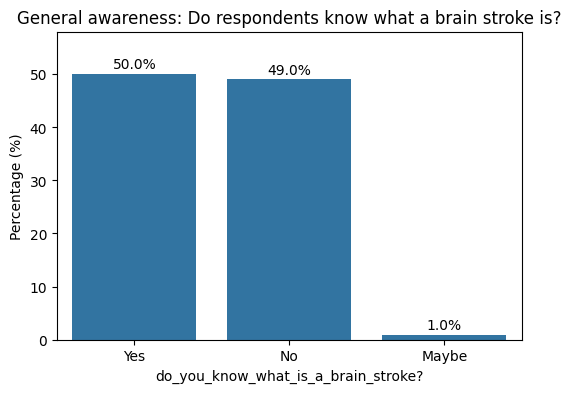

In [6]:


# Replace with your real column name if different
col = "do_you_know_what_is_a_brain_stroke?"



# Or compute from df:
counts = df[col].value_counts()

# Percentages
pct = counts / counts.sum() * 100
print("Counts:\n", counts)
print("\nPercentages:\n", pct.round(2))

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=pct.index, y=pct.values)
plt.ylabel("Percentage (%)")
plt.title("General awareness: Do respondents know what a brain stroke is?")
for i, v in enumerate(pct.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, max(pct.values) + 8)
plt.show()


In [11]:
# Mapping only for visualization
visual_labels = {
    "do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?": "Speech/Confusion",
    "do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?": "Numbness/Weakness",
    "do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?": "Nosebleed",
    "do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?": "Vision Problems"
}

symptom_cols = list(visual_labels.keys())


In [12]:

# Create a summary DataFrame
symptom_summary = pd.DataFrame({
    col: df[col].value_counts(normalize=True) * 100 for col in symptom_cols
}).fillna(0).T

# Rename columns for easier understanding
symptom_summary.rename(columns={"yes": "Yes (%)", "maybe": "Maybe (%)", "no": "No (%)"}, inplace=True)

# Add readable labels
symptom_summary.index = symptom_summary.index.map(visual_labels)


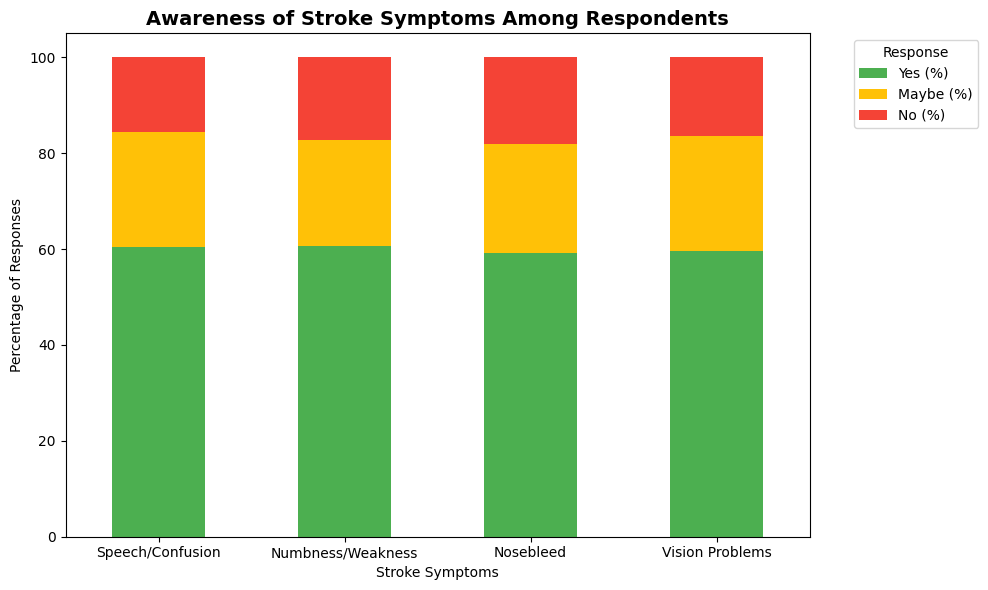

In [13]:
# Plotting
symptom_summary[["Yes (%)", "Maybe (%)", "No (%)"]].plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=["#4CAF50", "#FFC107", "#F44336"]
)

plt.title("Awareness of Stroke Symptoms Among Respondents", fontsize=14, weight='bold')
plt.ylabel("Percentage of Responses")
plt.xlabel("Stroke Symptoms")
plt.xticks(rotation=0)
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


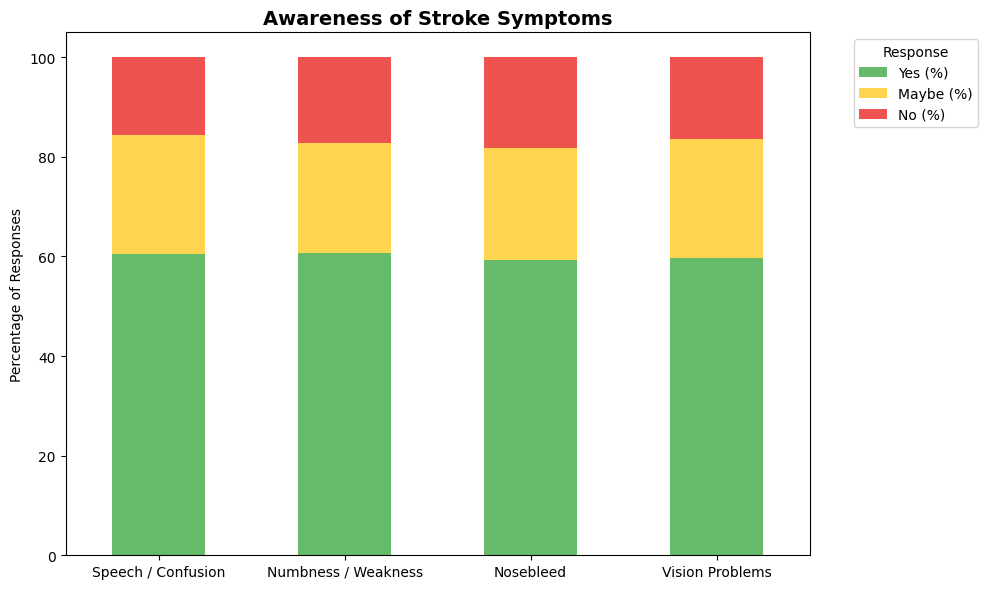

In [23]:
visual_labels = {
    "do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?": "Speech / Confusion",
    "do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?": "Numbness / Weakness",
    "do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?": "Nosebleed",
    "do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?": "Vision Problems"
}

symptom_cols = list(visual_labels.keys())

symptom_summary = pd.DataFrame({
    col: df[col].value_counts(normalize=True) * 100 for col in symptom_cols
}).fillna(0).T

symptom_summary.rename(columns={"yes": "Yes (%)", "maybe": "Maybe (%)", "no": "No (%)"}, inplace=True)
symptom_summary.index = symptom_summary.index.map(visual_labels)

# Plot
symptom_summary[["Yes (%)", "Maybe (%)", "No (%)"]].plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=["#66BB6A", "#FFD54F", "#EF5350"]
)
plt.title("Awareness of Stroke Symptoms", fontsize=14, weight='bold')
plt.ylabel("Percentage of Responses")
plt.xticks(rotation=0)
plt.legend(title="Response", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\3044833997.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="gender", y="awareness_score", palette="coolwarm", ci=None)
C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\3044833997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="gender", y="awareness_score", palette="coolwarm", ci=None)


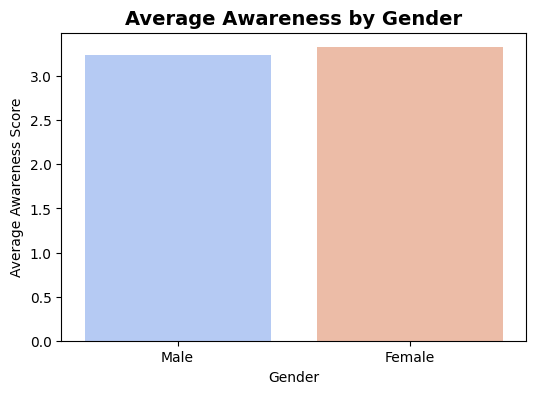

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="gender", y="awareness_score", palette="coolwarm", ci=None)
plt.title("Average Awareness by Gender", fontsize=14, weight='bold')
plt.ylabel("Average Awareness Score")
plt.xlabel("Gender")
plt.show()


C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\135079052.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="awareness_score", y="age", palette="crest", ci=None)
C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\135079052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="awareness_score", y="age", palette="crest", ci=None)


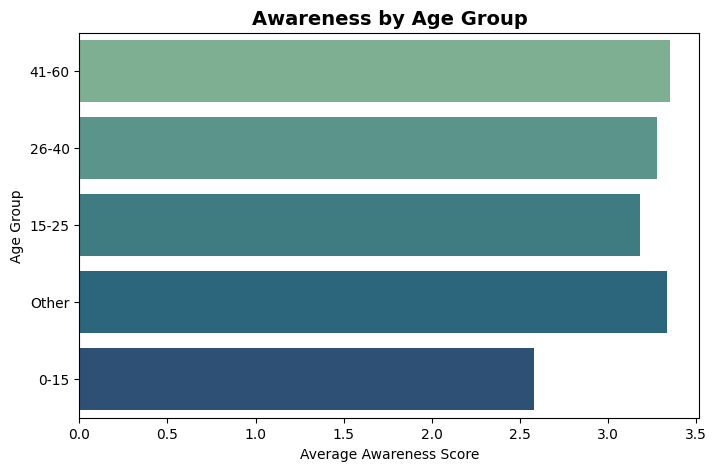

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="awareness_score", y="age", palette="crest", ci=None)
plt.title("Awareness by Age Group", fontsize=14, weight='bold')
plt.xlabel("Average Awareness Score")
plt.ylabel("Age Group")
plt.show()


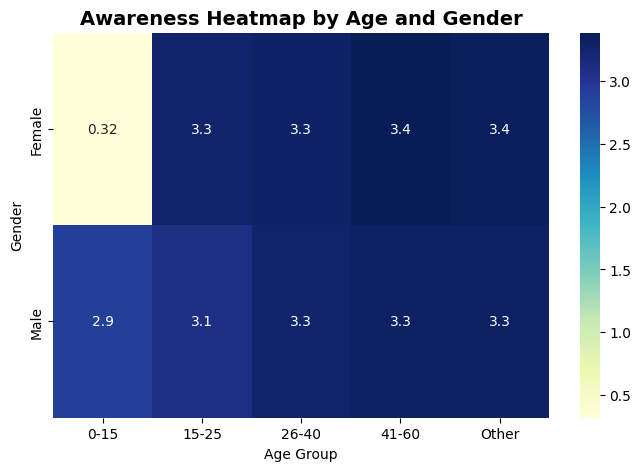

In [27]:
pivot = df.pivot_table(values="awareness_score", index="gender", columns="age", aggfunc="mean")

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Awareness Heatmap by Age and Gender", fontsize=14, weight='bold')
plt.xlabel("Age Group")
plt.ylabel("Gender")
plt.show()



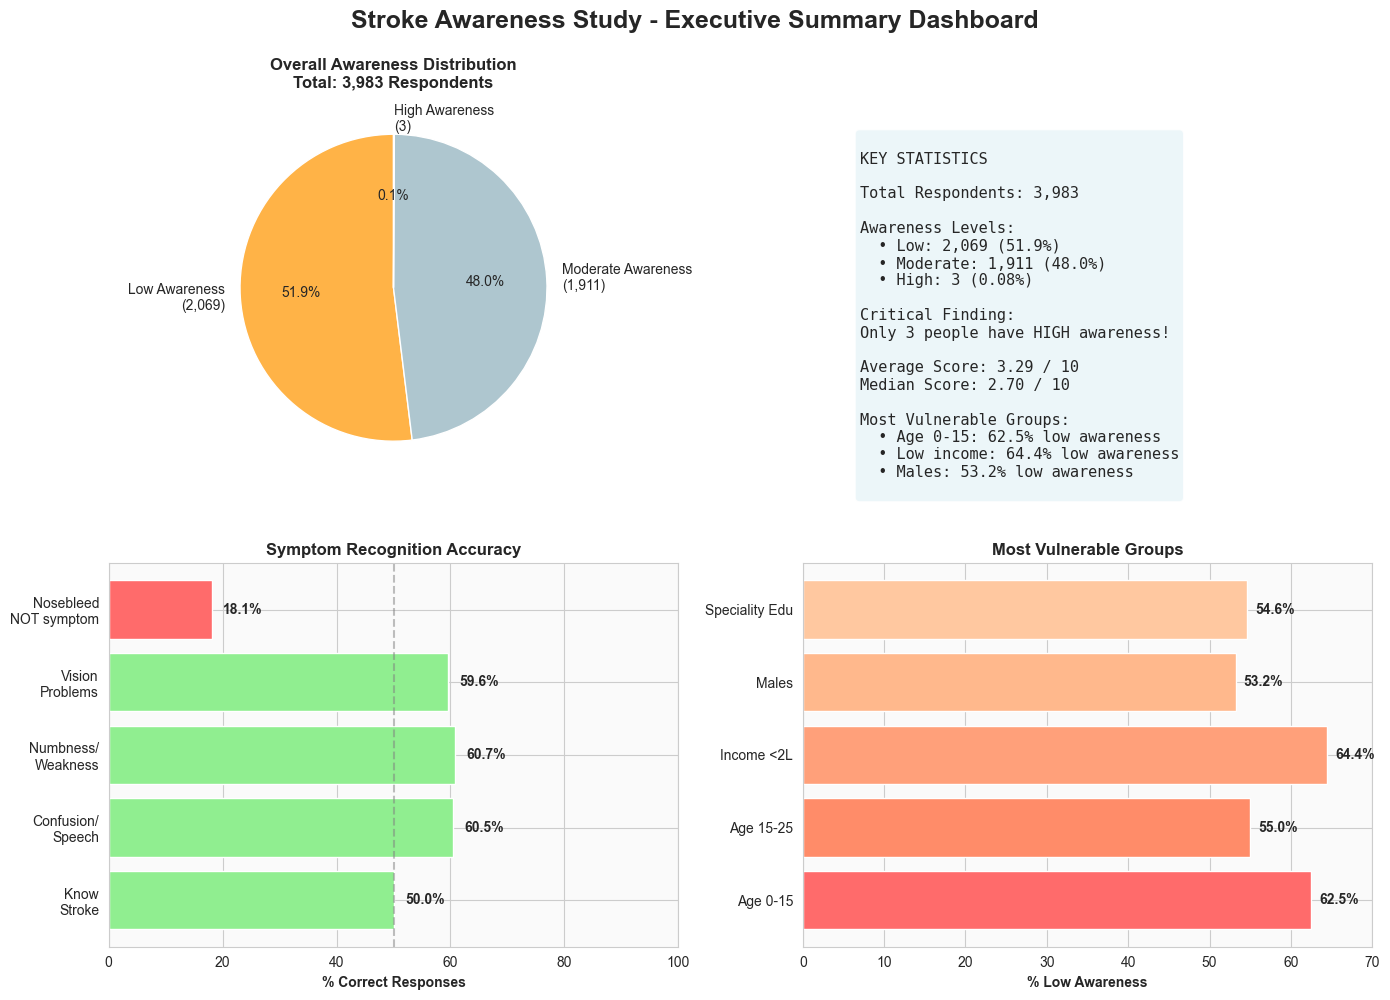


📊 VISUALIZING: AGE-BASED INSIGHTS


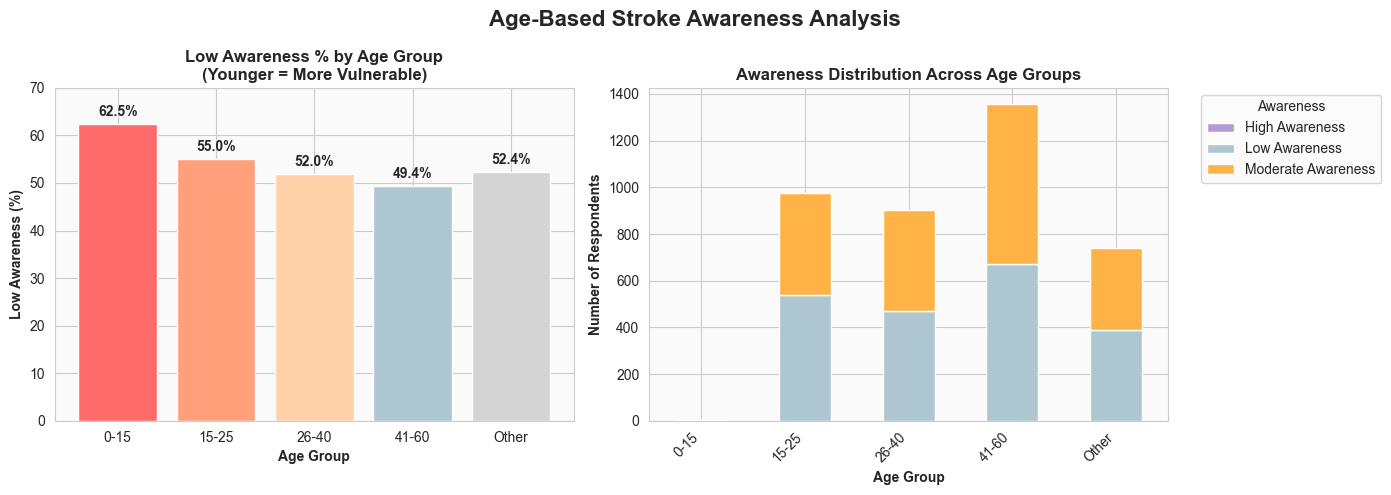


💰 VISUALIZING: INCOME-BASED DISPARITIES


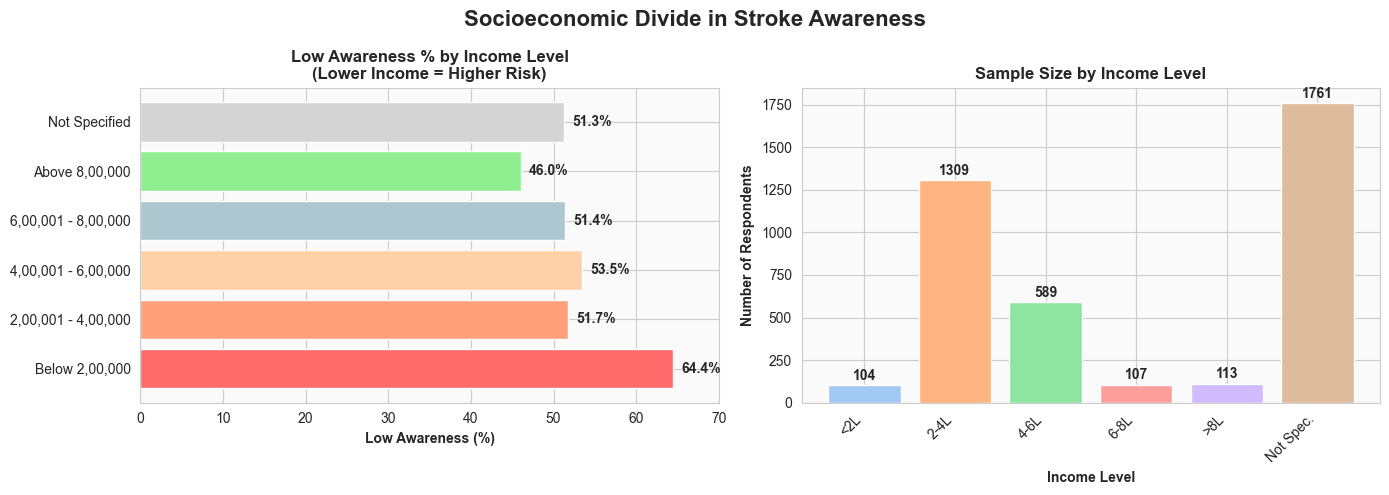


🚨 VISUALIZING: THE NOSEBLEED MISCONCEPTION


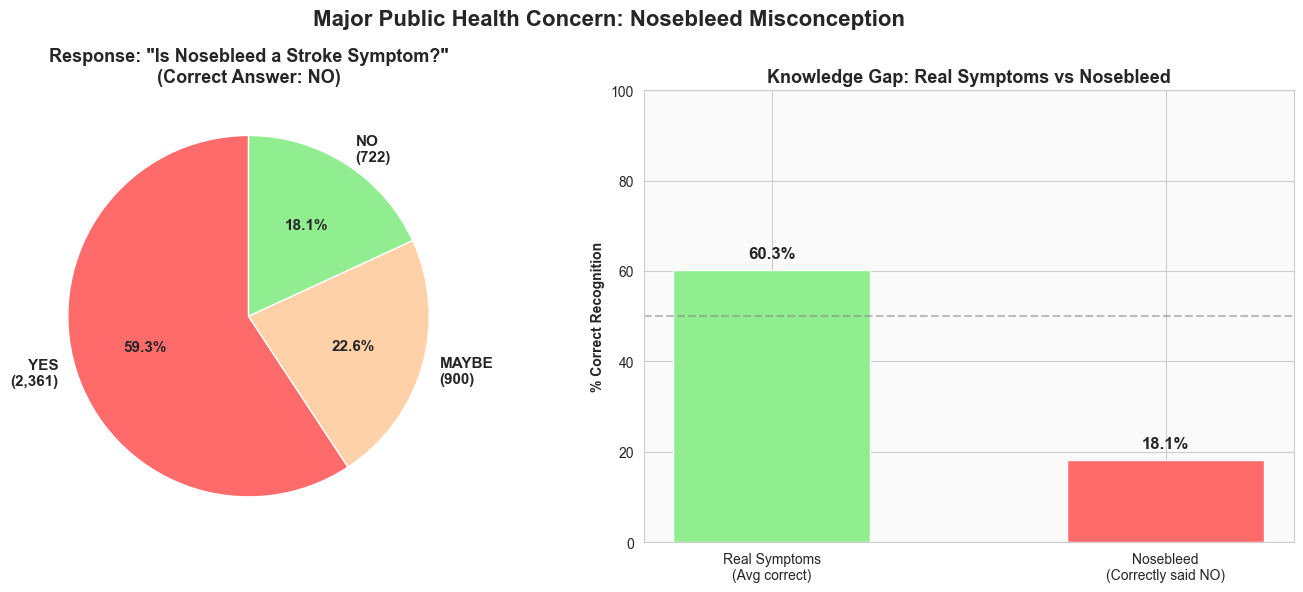


🎯 VISUALIZING: OVERALL SYMPTOM KNOWLEDGE LEVELS


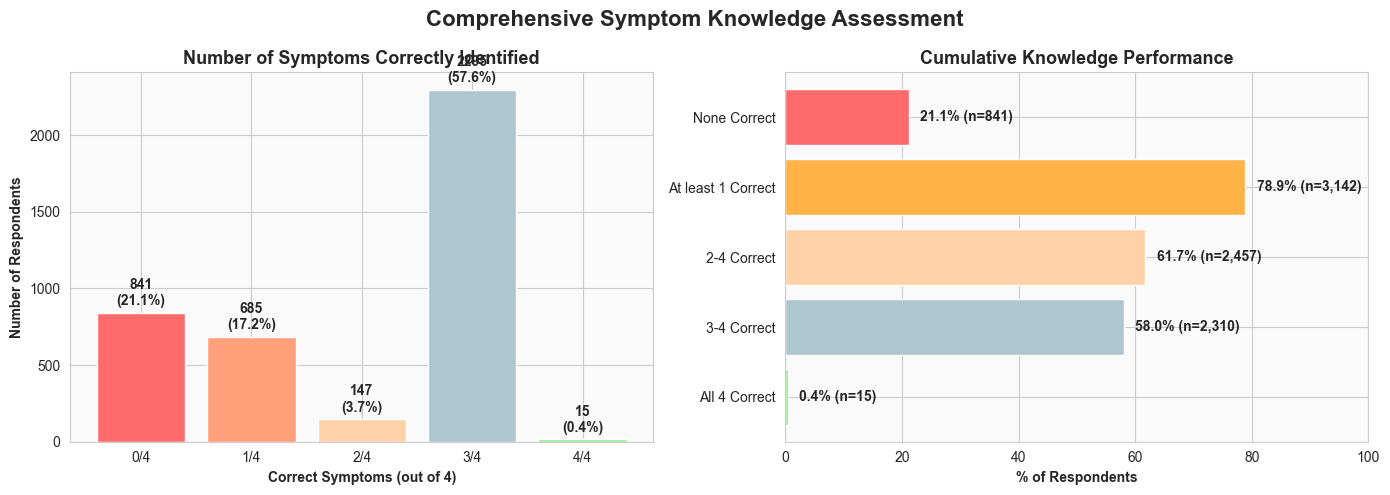


⚧📚 VISUALIZING: GENDER & EDUCATION PATTERNS


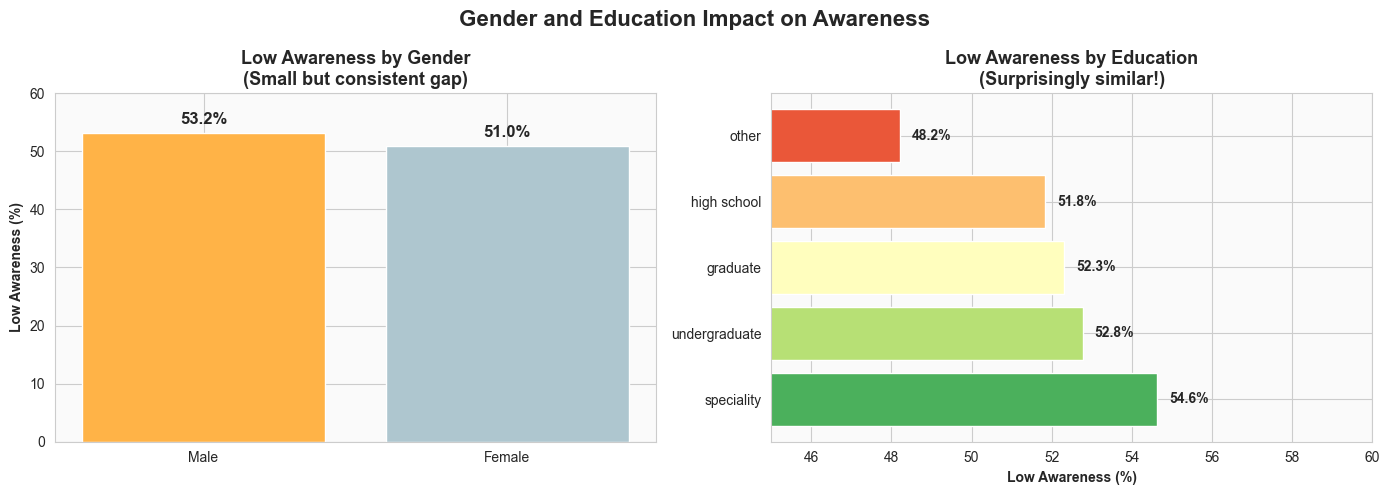


✅ ALL VISUALIZATIONS COMPLETE!

Key files created:
  - stroke_awareness_summary.csv (downloadable summary)

All charts show COUNT-BASED data (not averages) with subtle, professional colors


In [30]:


# Set up elegant, subtle color scheme
sns.set_palette("pastel")
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#FAFAFA'



# ============================================
# STEP 1: EXECUTIVE SUMMARY VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stroke Awareness Study - Executive Summary Dashboard', fontsize=18, fontweight='bold', y=0.995)

# 1.1 Overall Awareness Distribution (Pie)
category_counts = df['awareness_category'].value_counts()
colors_pie = ['#FFB347', '#AEC6CF', '#90EE90']
axes[0, 0].pie(category_counts, labels=[f"{cat}\n({count:,})" for cat, count in category_counts.items()], 
               autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 10})
axes[0, 0].set_title('Overall Awareness Distribution\nTotal: 3,983 Respondents', fontweight='bold', fontsize=12)

# 1.2 Key Statistics
axes[0, 1].axis('off')
stats_text = f"""
KEY STATISTICS

Total Respondents: 3,983

Awareness Levels:
  • Low: 2,069 (51.9%)
  • Moderate: 1,911 (48.0%)
  • High: 3 (0.08%)

Critical Finding:
Only 3 people have HIGH awareness!

Average Score: {df['awareness_score'].mean():.2f} / 10
Median Score: {df['awareness_score'].median():.2f} / 10

Most Vulnerable Groups:
  • Age 0-15: 62.5% low awareness
  • Low income: 64.4% low awareness
  • Males: 53.2% low awareness
"""
axes[0, 1].text(0.1, 0.9, stats_text, transform=axes[0, 1].transAxes, 
                fontsize=11, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='#E8F4F8', alpha=0.8))

# 1.3 Symptom Knowledge Overview
symptom_correct = {
    'Know\nStroke': (df['do_you_know_what_is_a_brain_stroke?'] == 'Yes').sum() / len(df) * 100,
    'Confusion/\nSpeech': (df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'] == 'yes').sum() / len(df) * 100,
    'Numbness/\nWeakness': (df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'] == 'yes').sum() / len(df) * 100,
    'Vision\nProblems': (df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'] == 'yes').sum() / len(df) * 100,
    'Nosebleed\nNOT symptom': (df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'] == 'no').sum() / len(df) * 100
}

bars = axes[1, 0].barh(list(symptom_correct.keys()), list(symptom_correct.values()), 
                        color=['#90EE90', '#90EE90', '#90EE90', '#90EE90', '#FF6B6B'])
axes[1, 0].set_xlabel('% Correct Responses', fontweight='bold')
axes[1, 0].set_title('Symptom Recognition Accuracy', fontweight='bold', fontsize=12)
axes[1, 0].set_xlim(0, 100)
axes[1, 0].axvline(x=50, color='gray', linestyle='--', alpha=0.5)

for i, (bar, val) in enumerate(zip(bars, symptom_correct.values())):
    axes[1, 0].text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                    va='center', fontweight='bold', fontsize=10)

# 1.4 Top Vulnerable Demographics
vulnerable_data = {
    'Age 0-15': 62.5,
    'Age 15-25': 55.0,
    'Income <2L': 64.4,
    'Males': 53.2,
    'Speciality Edu': 54.6
}

bars = axes[1, 1].barh(list(vulnerable_data.keys()), list(vulnerable_data.values()), 
                        color=['#FF6B6B', '#FF8C69', '#FFA07A', '#FFB88C', '#FFC8A0'])
axes[1, 1].set_xlabel('% Low Awareness', fontweight='bold')
axes[1, 1].set_title('Most Vulnerable Groups', fontweight='bold', fontsize=12)
axes[1, 1].set_xlim(0, 70)

for i, (bar, val) in enumerate(zip(bars, vulnerable_data.values())):
    axes[1, 1].text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                    va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# STEP 2: DEMOGRAPHIC DEEP DIVE - AGE
# ============================================

print("\n" + "="*80)
print("📊 VISUALIZING: AGE-BASED INSIGHTS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age-Based Stroke Awareness Analysis', fontsize=16, fontweight='bold')

# 2.1 Low Awareness by Age
age_awareness = pd.crosstab(df['age'], df['awareness_category'], normalize='index') * 100
age_order = ['0-15', '15-25', '26-40', '41-60', 'Other']
age_low = age_awareness['Low Awareness'].reindex(age_order)

colors_age = ['#FF6B6B', '#FFA07A', '#FFD1A9', '#AEC6CF', '#D4D4D4']
bars = axes[0].bar(age_low.index, age_low.values, color=colors_age)
axes[0].set_title('Low Awareness % by Age Group\n(Younger = More Vulnerable)', fontweight='bold')
axes[0].set_ylabel('Low Awareness (%)', fontweight='bold')
axes[0].set_xlabel('Age Group', fontweight='bold')
axes[0].set_ylim(0, 70)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2.2 Stacked: Awareness Categories by Age
awareness_by_age = pd.crosstab(df['age'], df['awareness_category']).reindex(age_order)
awareness_by_age.plot(kind='bar', stacked=True, ax=axes[1], 
                      color=['#B19CD9', '#AEC6CF', '#FFB347'])
axes[1].set_title('Awareness Distribution Across Age Groups', fontweight='bold')
axes[1].set_ylabel('Number of Respondents', fontweight='bold')
axes[1].set_xlabel('Age Group', fontweight='bold')
axes[1].legend(title='Awareness', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ============================================
# STEP 3: SOCIOECONOMIC ANALYSIS - INCOME
# ============================================

print("\n" + "="*80)
print("💰 VISUALIZING: INCOME-BASED DISPARITIES")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Socioeconomic Divide in Stroke Awareness', fontsize=16, fontweight='bold')

# 3.1 Low Awareness by Salary
salary_awareness = pd.crosstab(df['salary'], df['awareness_category'], normalize='index') * 100
salary_order = ['Below 2,00,000', '2,00,001 - 4,00,000', '4,00,001 - 6,00,000', 
                '6,00,001 - 8,00,000', 'Above 8,00,000', 'Not Specified']
salary_low = salary_awareness['Low Awareness'].reindex(salary_order)

colors_salary = ['#FF6B6B', '#FFA07A', '#FFD1A9', '#AEC6CF', '#90EE90', '#D4D4D4']
bars = axes[0].barh(salary_low.index, salary_low.values, color=colors_salary)
axes[0].set_title('Low Awareness % by Income Level\n(Lower Income = Higher Risk)', fontweight='bold')
axes[0].set_xlabel('Low Awareness (%)', fontweight='bold')
axes[0].set_xlim(0, 70)

for i, (bar, val) in enumerate(zip(bars, salary_low.values)):
    if not np.isnan(val):
        axes[0].text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                     va='center', fontweight='bold')

# 3.2 Count distribution
salary_counts = df['salary'].value_counts().reindex(salary_order)
bars = axes[1].bar(range(len(salary_counts)), salary_counts.values, 
                   color=sns.color_palette("pastel", len(salary_counts)))
axes[1].set_title('Sample Size by Income Level', fontweight='bold')
axes[1].set_ylabel('Number of Respondents', fontweight='bold')
axes[1].set_xlabel('Income Level', fontweight='bold')
axes[1].set_xticks(range(len(salary_counts)))
axes[1].set_xticklabels(['<2L', '2-4L', '4-6L', '6-8L', '>8L', 'Not Spec.'], rotation=45, ha='right')

for i, (bar, val) in enumerate(zip(bars, salary_counts.values)):
    axes[1].text(i, val + 30, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# STEP 4: SYMPTOM KNOWLEDGE - THE NOSEBLEED PROBLEM
# ============================================

print("\n" + "="*80)
print("🚨 VISUALIZING: THE NOSEBLEED MISCONCEPTION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Major Public Health Concern: Nosebleed Misconception', fontsize=16, fontweight='bold')

# 4.1 Nosebleed response distribution
nosebleed_resp = df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'].value_counts()
colors_nose = ['#FF6B6B', '#FFD1A9', '#90EE90']  # yes=red, maybe=orange, no=green
axes[0].pie(nosebleed_resp, labels=[f"{k.upper()}\n({v:,})" for k, v in nosebleed_resp.items()],
            autopct='%1.1f%%', colors=colors_nose, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Response: "Is Nosebleed a Stroke Symptom?"\n(Correct Answer: NO)', fontweight='bold', fontsize=13)

# 4.2 Comparison: Correct vs Incorrect beliefs
comparison_data = {
    'Real Symptoms\n(Avg correct)': (
        (df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'] == 'yes').sum() +
        (df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'] == 'yes').sum() +
        (df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'] == 'yes').sum()
    ) / 3 / len(df) * 100,
    'Nosebleed\n(Correctly said NO)': (df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'] == 'no').sum() / len(df) * 100
}

bars = axes[1].bar(list(comparison_data.keys()), list(comparison_data.values()), 
                   color=['#90EE90', '#FF6B6B'], width=0.5)
axes[1].set_title('Knowledge Gap: Real Symptoms vs Nosebleed', fontweight='bold', fontsize=13)
axes[1].set_ylabel('% Correct Recognition', fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2,
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================
# STEP 5: COMPREHENSIVE SYMPTOM KNOWLEDGE
# ============================================

print("\n" + "="*80)
print("🎯 VISUALIZING: OVERALL SYMPTOM KNOWLEDGE LEVELS")
print("="*80)

# Calculate correct symptoms
df['correct_symptoms'] = (
    (df['do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?'] == 'yes').astype(int) +
    (df['do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?'] == 'yes').astype(int) +
    (df['do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?'] == 'yes').astype(int) +
    (df['do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?'] == 'no').astype(int)
)

symptom_knowledge = df['correct_symptoms'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comprehensive Symptom Knowledge Assessment', fontsize=16, fontweight='bold')

# 5.1 Distribution of correct answers
colors_knowledge = ['#FF6B6B', '#FFA07A', '#FFD1A9', '#AEC6CF', '#90EE90']
bars = axes[0].bar([f'{i}/4' for i in symptom_knowledge.index], symptom_knowledge.values, color=colors_knowledge)
axes[0].set_title('Number of Symptoms Correctly Identified', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Respondents', fontweight='bold')
axes[0].set_xlabel('Correct Symptoms (out of 4)', fontweight='bold')

for bar, val in zip(bars, symptom_knowledge.values):
    height = bar.get_height()
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 30,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 5.2 Cumulative performance
cumulative_data = {
    'All 4 Correct': (df['correct_symptoms'] == 4).sum(),
    '3-4 Correct': (df['correct_symptoms'] >= 3).sum(),
    '2-4 Correct': (df['correct_symptoms'] >= 2).sum(),
    'At least 1 Correct': (df['correct_symptoms'] >= 1).sum(),
    'None Correct': (df['correct_symptoms'] == 0).sum()
}

bars = axes[1].barh(list(cumulative_data.keys())[:4], 
                     [cumulative_data[k]/len(df)*100 for k in list(cumulative_data.keys())[:4]], 
                     color=['#90EE90', '#AEC6CF', '#FFD1A9', '#FFB347'])
axes[1].barh(['None Correct'], [cumulative_data['None Correct']/len(df)*100], color='#FF6B6B')
axes[1].set_title('Cumulative Knowledge Performance', fontweight='bold', fontsize=13)
axes[1].set_xlabel('% of Respondents', fontweight='bold')
axes[1].set_xlim(0, 100)

for i, (key, bar) in enumerate(zip(list(cumulative_data.keys()), axes[1].patches)):
    width = bar.get_width()
    count = cumulative_data[key]
    axes[1].text(width + 2, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}% (n={count:,})', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# STEP 6: GENDER + EDUCATION INSIGHTS
# ============================================

print("\n" + "="*80)
print("⚧📚 VISUALIZING: GENDER & EDUCATION PATTERNS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gender and Education Impact on Awareness', fontsize=16, fontweight='bold')

# 6.1 Gender comparison
gender_awareness = pd.crosstab(df['gender'], df['awareness_category'], normalize='index') * 100
gender_low = gender_awareness['Low Awareness'].sort_values(ascending=False)

bars = axes[0].bar(gender_low.index, gender_low.values, color=['#FFB347', '#AEC6CF'])
axes[0].set_title('Low Awareness by Gender\n(Small but consistent gap)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Low Awareness (%)', fontweight='bold')
axes[0].set_ylim(0, 60)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 6.2 Education - showing similarity
education_awareness = pd.crosstab(df['educational_level'], df['awareness_category'], normalize='index') * 100
education_low = education_awareness['Low Awareness'].sort_values(ascending=False)

bars = axes[1].barh(education_low.index, education_low.values, 
                     color=sns.color_palette("RdYlGn_r", len(education_low)))
axes[1].set_title('Low Awareness by Education\n(Surprisingly similar!)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Low Awareness (%)', fontweight='bold')
axes[1].set_xlim(45, 60)

for i, (bar, val) in enumerate(zip(bars, education_low.values)):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                 va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("="*80)
print("\nKey files created:")
print("  - stroke_awareness_summary.csv (downloadable summary)")
print("\nAll charts show COUNT-BASED data (not averages) with subtle, professional colors")


C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\2076824517.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Harshali g\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


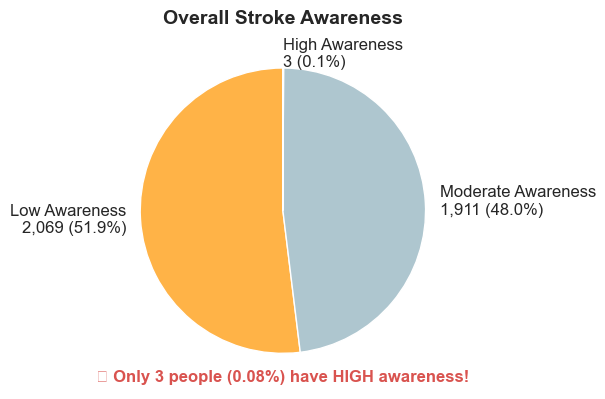

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\2076824517.py:41: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()


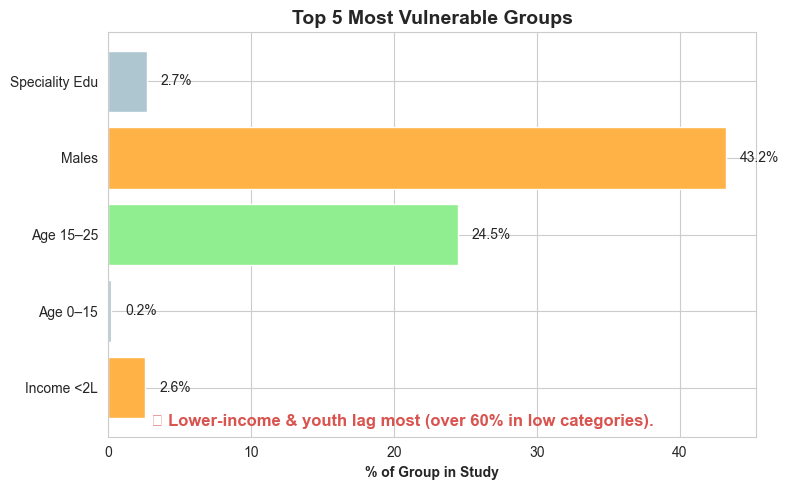

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\2076824517.py:64: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()


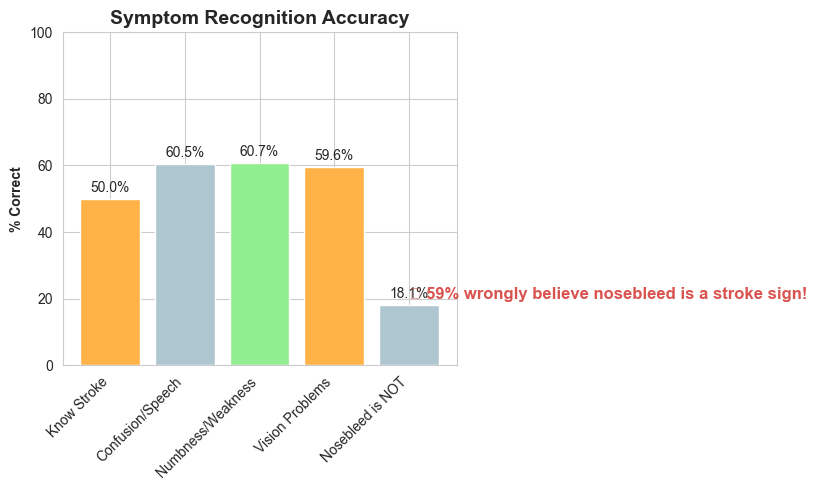

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\2076824517.py:83: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\2076824517.py:83: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Harshali g\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Harshali g\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


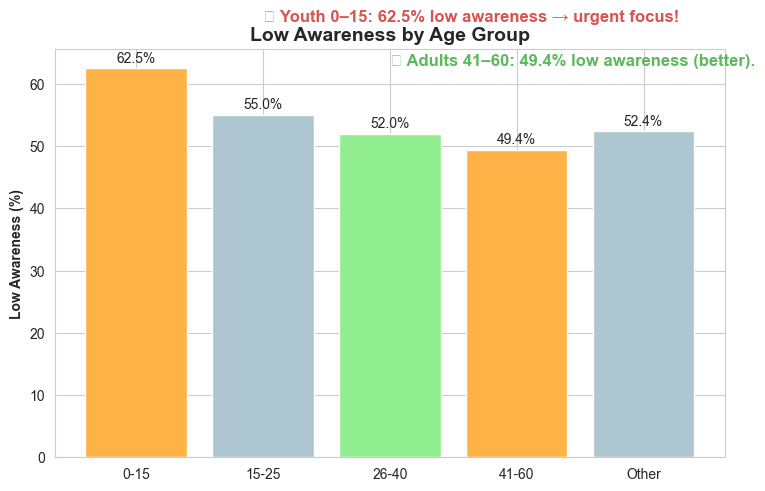

In [31]:

total = len(df)

sns.set_palette("pastel")
sns.set_style("whitegrid")

# 1. Overall Awareness Pie with Insight
category_counts = df['awareness_category'].value_counts()
plt.figure(figsize=(6,6))
colors = ['#FFB347','#AEC6CF','#90EE90']
wedges, texts, autotexts = plt.pie(
    category_counts,
    labels=[f"{cat}\n{count:,} ({count/total*100:.1f}%)" 
            for cat, count in category_counts.items()],
    autopct='', colors=colors, startangle=90, textprops={'fontsize':12}
)
plt.title("Overall Stroke Awareness", fontsize=14, fontweight='bold')
# Insight callout
plt.text(0, -1.2, "🔴 Only 3 people (0.08%) have HIGH awareness!", 
         ha='center', fontsize=12, fontweight='bold', color='#D9534F')
plt.tight_layout()
plt.show()

# 2. Vulnerable Groups Bar with Insight
vuln = {
    'Income <2L': df[df['salary']=='Below 2,00,000'].shape[0]/total*100,
    'Age 0–15': df[df['age']=='0-15'].shape[0]/total*100,
    'Age 15–25': df[df['age']=='15-25'].shape[0]/total*100,
    'Males': df[df['gender']=='Male'].shape[0]/total*100,
    'Speciality Edu': df[df['educational_level']=='speciality'].shape[0]/total*100
}
plt.figure(figsize=(8,5))
bars = plt.barh(list(vuln.keys()), list(vuln.values()), color=colors[:5])
plt.xlabel("% of Group in Study", fontweight='bold')
plt.title("Top 5 Most Vulnerable Groups", fontsize=14, fontweight='bold')
for bar in bars:
    x = bar.get_width()
    plt.text(x+1, bar.get_y()+bar.get_height()/2, f"{x:.1f}%", va='center')
# Insight
plt.text(3, -0.5, "🔴 Lower-income & youth lag most (over 60% in low categories).", 
         color='#D9534F', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Symptom Recognition Accuracy with Insight
symptom_accuracy = {
    'Know Stroke': (df['do_you_know_what_is_a_brain_stroke?']=='Yes').mean()*100,
    'Confusion/Speech': (df.iloc[:,3]=='yes').mean()*100,
    'Numbness/Weakness': (df.iloc[:,4]=='yes').mean()*100,
    'Vision Problems': (df.iloc[:,6]=='yes').mean()*100,
    'Nosebleed is NOT': (df.iloc[:,5]=='no').mean()*100
}
plt.figure(figsize=(8,5))
bars = plt.bar(list(symptom_accuracy.keys()), list(symptom_accuracy.values()), color=colors)
plt.ylim(0,100)
plt.ylabel("% Correct", fontweight='bold')
plt.title("Symptom Recognition Accuracy", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+2, f"{y:.1f}%", ha='center')
# Insight
plt.text(4, 20, "🔴 59% wrongly believe nosebleed is a stroke sign!", 
         color='#D9534F', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Low Awareness % by Age with Dual Insight
age_low = pd.crosstab(df['age'], df['awareness_category'], normalize='index')['Low Awareness']*100
order = ['0-15','15-25','26-40','41-60','Other']
age_low = age_low.reindex(order)
plt.figure(figsize=(8,5))
bars = plt.bar(order, age_low.values, color=colors)
plt.ylabel("Low Awareness (%)", fontweight='bold')
plt.title("Low Awareness by Age Group", fontsize=14, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.1f}%", ha='center')
# Dual insight
plt.text(1, 70, "🔴 Youth 0–15: 62.5% low awareness → urgent focus!", 
         fontsize=12, fontweight='bold', color='#D9534F')
plt.text(2, 63, "🟢 Adults 41–60: 49.4% low awareness (better).", 
         fontsize=12, fontweight='bold', color='#5CB85C')
plt.tight_layout()
plt.show()


C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\923079379.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Harshali g\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


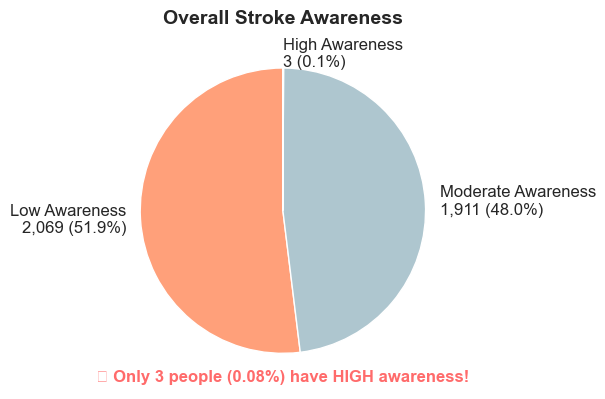

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\923079379.py:51: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()


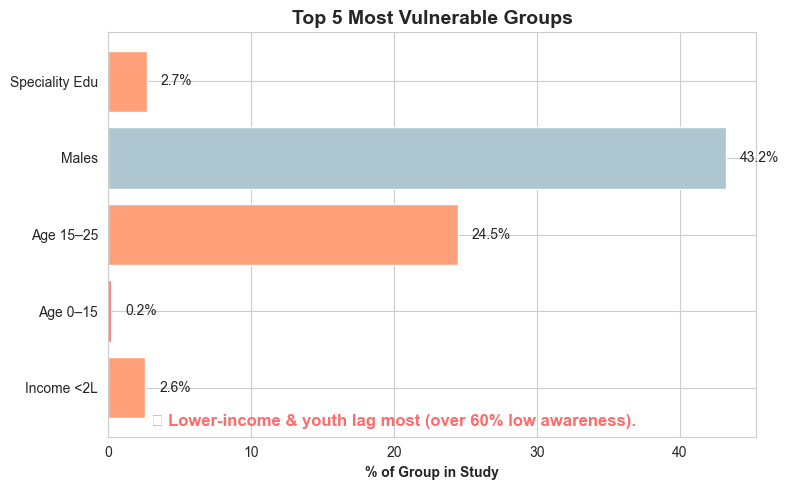

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\923079379.py:76: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()


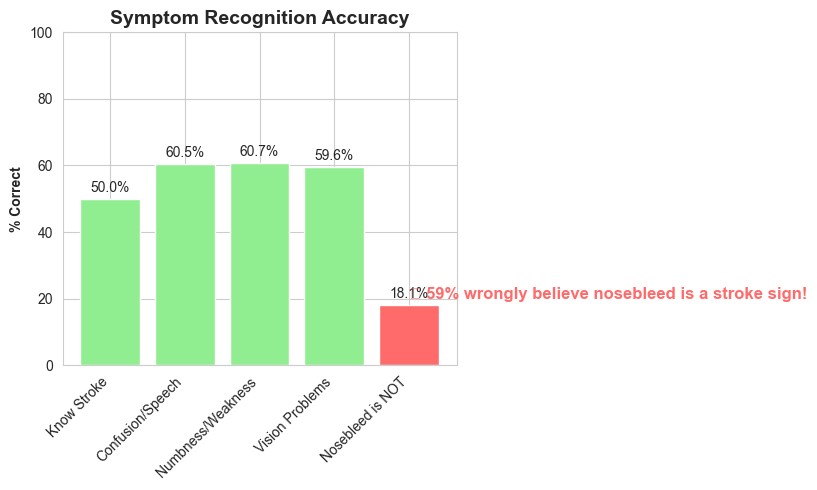

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\923079379.py:97: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Harshali g\AppData\Local\Temp\ipykernel_10808\923079379.py:97: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Harshali g\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Harshali g\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


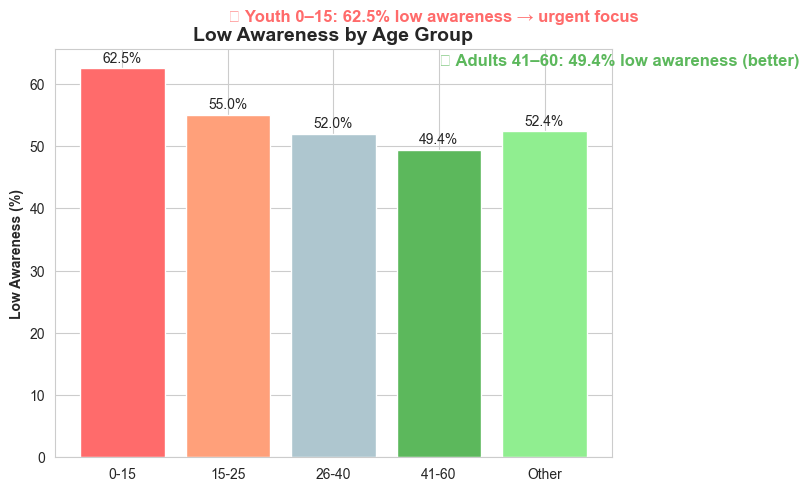

In [32]:

total = len(df)

# Define palette
# Warning (low awareness, errors): red tones
COLOR_WARN   = "#FF6B6B"  # strong warning
COLOR_ALERT  = "#FFA07A"  # moderate warning
# Neutral context: pastel blues/greens
COLOR_NEUTRAL1 = "#AEC6CF"  # pastel blue
COLOR_NEUTRAL2 = "#90EE90"  # pastel green
# Highlight positive / success
COLOR_POS    = "#5CB85C"  # bootstrap success green

# 1. Overall Awareness Pie with Insight
category_counts = df['awareness_category'].value_counts()
plt.figure(figsize=(6,6))
colors_pie = [COLOR_ALERT, COLOR_NEUTRAL1, COLOR_NEUTRAL2]
# Order: Low Awareness (orange), Moderate (blue), High (green)
plt.pie(
    category_counts,
    labels=[f"{cat}\n{count:,} ({count/total*100:.1f}%)"
            for cat, count in category_counts.items()],
    colors=colors_pie,
    startangle=90, textprops={'fontsize':12}
)
plt.title("Overall Stroke Awareness", fontsize=14, fontweight='bold')
plt.text(0, -1.2,
         "🔴 Only 3 people (0.08%) have HIGH awareness!",
         ha='center', fontsize=12, fontweight='bold', color=COLOR_WARN)
plt.tight_layout()
plt.show()

# 2. Vulnerable Groups Bar with Insight
vuln = {
    'Income <2L': df[df['salary']=='Below 2,00,000'].shape[0]/total*100,
    'Age 0–15':  df[df['age']=='0-15'].shape[0]/total*100,
    'Age 15–25': df[df['age']=='15-25'].shape[0]/total*100,
    'Males':     df[df['gender']=='Male'].shape[0]/total*100,
    'Speciality Edu': df[df['educational_level']=='speciality'].shape[0]/total*100
}
plt.figure(figsize=(8,5))
bars = plt.barh(list(vuln.keys()), list(vuln.values()),
                color=[COLOR_ALERT, COLOR_WARN, COLOR_ALERT, COLOR_NEUTRAL1, COLOR_ALERT])
plt.xlabel("% of Group in Study", fontweight='bold')
plt.title("Top 5 Most Vulnerable Groups", fontsize=14, fontweight='bold')
for bar in bars:
    x = bar.get_width()
    plt.text(x+1, bar.get_y()+bar.get_height()/2, f"{x:.1f}%", va='center')
plt.text(3, -0.5,
         "🔴 Lower-income & youth lag most (over 60% low awareness).",
         color=COLOR_WARN, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Symptom Recognition Accuracy with Insight
# Columns are in order: Know stroke, confusion, numbness, vision, nosebleed
symptom_accuracy = {
    'Know Stroke': (df['do_you_know_what_is_a_brain_stroke?']=='Yes').mean()*100,
    'Confusion/Speech': (df.iloc[:,3]=='yes').mean()*100,
    'Numbness/Weakness': (df.iloc[:,4]=='yes').mean()*100,
    'Vision Problems': (df.iloc[:,6]=='yes').mean()*100,
    'Nosebleed is NOT': (df.iloc[:,5]=='no').mean()*100
}
plt.figure(figsize=(8,5))
bars = plt.bar(list(symptom_accuracy.keys()), list(symptom_accuracy.values()),
               color=[COLOR_NEUTRAL2, COLOR_NEUTRAL2, COLOR_NEUTRAL2, COLOR_NEUTRAL2, COLOR_WARN])
plt.ylim(0,100)
plt.ylabel("% Correct", fontweight='bold')
plt.title("Symptom Recognition Accuracy", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+2, f"{y:.1f}%", ha='center')
plt.text(4, 20,
         "🔴 59% wrongly believe nosebleed is a stroke sign!",
         color=COLOR_WARN, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Low Awareness % by Age with Dual Insight
age_low = pd.crosstab(df['age'], df['awareness_category'], normalize='index')['Low Awareness']*100
order = ['0-15','15-25','26-40','41-60','Other']
age_low = age_low.reindex(order)
plt.figure(figsize=(8,5))
bars = plt.bar(order, age_low.values,
               color=[COLOR_WARN, COLOR_ALERT, COLOR_NEUTRAL1, COLOR_POS, COLOR_NEUTRAL2])
plt.ylabel("Low Awareness (%)", fontweight='bold')
plt.title("Low Awareness by Age Group", fontsize=14, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.1f}%", ha='center')
plt.text(1, 70,
         "🔴 Youth 0–15: 62.5% low awareness → urgent focus",
         fontsize=12, fontweight='bold', color=COLOR_WARN)
plt.text(3, 63,
         "🟢 Adults 41–60: 49.4% low awareness (better)",
         fontsize=12, fontweight='bold', color=COLOR_POS)
plt.tight_layout()
plt.show()
